# Канівське водосховище — відновлення даних

## Мета дослідження

Гідрофізичні та гідрохімічні параметри водних екосистем перебувають у складних взаємозалежностях, що визначаються фізико-хімічними процесами. Проте натурні спостереження часто містять пропущені значення — через поломки приладів, несприятливі умови відбору або обмеження лабораторних методів. Наявність пропусків ускладнює статистичний аналіз і може призводити до зміщених оцінок.

У даній роботі для відновлення пропущених значень застосовується **регресійне відновлення** (*regression imputation*) — підхід, за якого пропущене значення цільової змінної прогнозується на основі наявних предикторів за допомогою навченої регресійної моделі.

## Методологічний підхід

На відміну від використання лише одного методу, в роботі реалізовано **порівняльний аналіз одинадцяти регресійних моделей**:

| № | Модель | Тип |
|---|--------|-----|
| 1 | Linear Regression (OLS) | Лінійна параметрична |
| 2 | Ridge Regression | Лінійна з L2-регуляризацією |
| 3 | Lasso Regression | Лінійна з L1-регуляризацією |
| 4 | ElasticNet | Лінійна з L1+L2-регуляризацією |
| 5 | Bayesian Ridge | Байєсівська лінійна |
| 6 | Random Forest | Ансамблева (bagging) |
| 7 | Gradient Boosting | Ансамблева (boosting) |
| 8 | Extra Trees | Ансамблева (randomized bagging) |
| 9 | AdaBoost | Ансамблева (adaptive boosting) |
| 10 | SVR (Support Vector Regression) | Ядрова нелінійна |
| 11 | KNN (K-Nearest Neighbors) | Непараметрична |

Для кожного цільового параметра всі увімкнені моделі навчаються на повних спостереженнях, оцінюються методом **k-fold крос-валідації**, після чого автоматично обирається найкраща модель за метрикою **CV R²**.

## Формульні параметри

Параметри `N_inorg` та `NP` не моделюються регресією, а обчислюються за формулами після заповнення їх складових:
- $N_{inorg} = NH_4 + NO_2 + NO_3$ (сума форм неорганічного азоту)
- $NP = N_{inorg} / P_{inorg}$ (масове співвідношення азоту до фосфору)

## 1. Імпорт бібліотек

In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
    div.output_scroll { height: unset !important; max-height: unset !important; }
    div.output_area { max-height: unset !important; }
    div.cell-output-ipywidget-background { max-height: unset !important; }
    :root { --jp-cell-output-max-height: unset !important; }
</style>
"""))

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Якщо запуск у Google Colab — завантаження файлів
# Потрібно завантажити: 'Дані.xlsx' та 'Дані_реальні.xlsx'
if os.path.exists('/content'):
    from google.colab import files
    print('Завантажте два файли: "Дані.xlsx" та "Дані_реальні.xlsx"')
    uploaded = files.upload()

print('Бібліотеки завантажено')

Бібліотеки завантажено


## 1.1. Конфігурація аналізу

**Всі параметри аналізу зібрані тут.** Змінюйте значення нижче, щоб налаштувати:
- які моделі використовувати (лінійні, ансамблеві, ядрові)
- поріг кореляції для автоматичного вибору предикторів
- кількість фолдів cross-validation
- цільові параметри для відновлення

Детальний опис кожної моделі, її математичний апарат та значення параметрів наведено в секції 1.2.

In [3]:
# =====================================================================
#  КОНФІГУРАЦІЯ — змінюйте тільки цей блок
# =====================================================================

CONFIG = {
    # --- Моделі для порівняння (True = увімкнена) ---
    'models': {
        'LinearRegression':   True,
        'Ridge':              True,
        'Lasso':              True,
        'ElasticNet':         True,
        'BayesianRidge':      True,
        'RandomForest':       True,
        'GradientBoosting':   True,
        'ExtraTrees':         True,
        'AdaBoost':           True,
        'SVR':                True,
        'KNN':                True,
    },

    # --- Поріг кореляції Пірсона для автоматичного вибору предикторів ---
    # Предиктори з |r| >= threshold будуть обрані автоматично
    'correlation_threshold': 0.5,

    # --- Мінімальна кількість предикторів для кожного target ---
    # Якщо за порогом знайдено менше — буде взято топ-N за кореляцією
    'min_predictors': 2,

    # --- Cross-validation ---
    'cv_folds': 5,

    # --- Стратегія вибору моделі для відновлення ---
    # 'auto' — автоматично обирається модель з найвищим CV R²
    'model_selection': 'auto',

    # --- Цільові параметри для відновлення пропусків ---
    'targets': ['TSS', 'NH4', 'NO2', 'NO3', 'P_inorg'],

    # --- Параметри, які НЕ можуть бути предикторами ---
    # (формульні / залежні від targets)
    'exclude_as_predictors': ['N_inorg', 'NP'],
}

# ----- Реєстр доступних моделей (не змінювати) -----
MODEL_REGISTRY = {
    'LinearRegression':   lambda: LinearRegression(),
    'Ridge':              lambda: Ridge(alpha=1.0),
    'Lasso':              lambda: Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet':         lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'BayesianRidge':      lambda: BayesianRidge(),
    'RandomForest':       lambda: RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':   lambda: GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ExtraTrees':         lambda: ExtraTreesRegressor(n_estimators=100, random_state=42),
    'AdaBoost':           lambda: AdaBoostRegressor(n_estimators=100, random_state=42),
    'SVR':                lambda: Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
    'KNN':                lambda: Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=5))]),
}

# Перевірка конфігурації
enabled_models = [name for name, on in CONFIG['models'].items() if on]
assert len(enabled_models) >= 1, 'Потрібно увімкнути хоча б одну модель!'
print(f'Увімкнені моделі: {enabled_models}')
print(f'Поріг кореляції: {CONFIG["correlation_threshold"]}')
print(f'CV фолдів: {CONFIG["cv_folds"]}')
print(f'Цільові параметри: {CONFIG["targets"]}')

Увімкнені моделі: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge', 'RandomForest', 'GradientBoosting', 'ExtraTrees', 'AdaBoost', 'SVR', 'KNN']
Поріг кореляції: 0.5
CV фолдів: 5
Цільові параметри: ['TSS', 'NH4', 'NO2', 'NO3', 'P_inorg']


## 1.2. Теоретичний опис моделей

Нижче наведено математичний апарат кожної з моделей, що використовуються в аналізі, а також пояснення параметрів конфігурації.

---

### 1.2.1. Лінійна регресія (Ordinary Least Squares, OLS)

**Математична модель:**

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p = X\boldsymbol{\beta}$$

де $X$ — матриця предикторів, $\boldsymbol{\beta}$ — вектор коефіцієнтів.

**Оптимізація:** мінімізація суми квадратів залишків (RSS):

$$\boldsymbol{\beta}^* = \arg\min_{\boldsymbol{\beta}} \|y - X\boldsymbol{\beta}\|^2_2$$

Аналітичний розв'язок: $\boldsymbol{\beta}^* = (X^T X)^{-1} X^T y$

**Параметри налаштування:** відсутні — модель не має гіперпараметрів.

**Переваги:** простота, інтерпретованість коефіцієнтів, швидкість навчання.
**Обмеження:** чутлива до мультиколінеарності, не здатна моделювати нелінійні залежності.

---

### 1.2.2. Ridge Regression (L2-регуляризація)

**Математична модель:** та сама лінійна модель, але з штрафом на величину коефіцієнтів:

$$\boldsymbol{\beta}^* = \arg\min_{\boldsymbol{\beta}} \left[ \|y - X\boldsymbol{\beta}\|^2_2 + \alpha \|\boldsymbol{\beta}\|^2_2 \right]$$

Штрафний член $\alpha \|\boldsymbol{\beta}\|^2_2$ зменшує величину коефіцієнтів, запобігаючи перенавчанню.

**Параметри налаштування:**
- **`alpha`** (за замовчуванням = 1.0) — сила регуляризації. Більше значення → сильніше стиснення коефіцієнтів до нуля. При `alpha = 0` модель еквівалентна OLS.

**Переваги:** стійкість до мультиколінеарності, менша дисперсія оцінок.
**Обмеження:** не виконує відбір ознак (всі коефіцієнти залишаються ненульовими).

---

### 1.2.3. Lasso Regression (L1-регуляризація)

**Математична модель:**

$$\boldsymbol{\beta}^* = \arg\min_{\boldsymbol{\beta}} \left[ \|y - X\boldsymbol{\beta}\|^2_2 + \alpha \|\boldsymbol{\beta}\|_1 \right]$$

L1-штраф ($\|\boldsymbol{\beta}\|_1 = \sum |\beta_j|$) може обнуляти окремі коефіцієнти, виконуючи вбудований відбір ознак.

**Параметри налаштування:**
- **`alpha`** (за замовчуванням = 0.01) — сила регуляризації. Більше значення → більше коефіцієнтів стають нульовими.
- **`max_iter`** (за замовчуванням = 10000) — максимальна кількість ітерацій координатного спуску для збіжності алгоритму.

**Переваги:** автоматичний відбір ознак, інтерпретованість.
**Обмеження:** при сильній кореляції між предикторами обирає лише один з них довільно.

---

### 1.2.4. ElasticNet (комбінація L1 + L2 регуляризації)

**Математична модель:**

$$\boldsymbol{\beta}^* = \arg\min_{\boldsymbol{\beta}} \left[ \|y - X\boldsymbol{\beta}\|^2_2 + \alpha \left( \rho \|\boldsymbol{\beta}\|_1 + \frac{1 - \rho}{2} \|\boldsymbol{\beta}\|^2_2 \right) \right]$$

де $\rho$ (`l1_ratio`) — баланс між L1 та L2 штрафами. При $\rho = 1$ модель еквівалентна Lasso, при $\rho = 0$ — Ridge.

**Параметри налаштування:**
- **`alpha`** (за замовчуванням = 0.01) — загальна сила регуляризації.
- **`l1_ratio`** (за замовчуванням = 0.5) — частка L1-штрафу. Значення 0.5 означає рівний баланс між Ridge та Lasso.
- **`max_iter`** (за замовчуванням = 10000) — максимальна кількість ітерацій.

**Переваги:** поєднує переваги Ridge (стабільність при мультиколінеарності) та Lasso (відбір ознак). Особливо корисна, коли предиктори корельовані між собою.
**Обмеження:** потребує налаштування двох гіперпараметрів замість одного.

---

### 1.2.5. Bayesian Ridge (Байєсівська лінійна регресія)

**Математична модель:** байєсівський підхід до лінійної регресії з апріорним розподілом на коефіцієнти:

$$p(\boldsymbol{\beta} | \alpha) = \mathcal{N}(\boldsymbol{0}, \alpha^{-1} \mathbf{I})$$
$$p(y | X, \boldsymbol{\beta}, \lambda) = \mathcal{N}(X\boldsymbol{\beta}, \lambda^{-1} \mathbf{I})$$

Параметри регуляризації $\alpha$ (точність апріорного розподілу коефіцієнтів) та $\lambda$ (точність шуму) оцінюються автоматично з даних через максимізацію маргінальної правдоподібності (evidence approximation).

**Параметри налаштування:** визначаються автоматично з даних — не потребує ручного налаштування гіперпараметрів.

**Переваги:** автоматичне визначення оптимальної сили регуляризації, стійкість на малих вибірках, можливість оцінки невизначеності прогнозу.
**Обмеження:** припускає нормальний розподіл помилок та лінійну залежність, повільніша за OLS.

---

### 1.2.6. Random Forest (Випадковий ліс)

**Математична модель:** ансамбль $B$ дерев рішень, кожне з яких навчається на випадковій бутстреп-вибірці та підмножині ознак:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

де $T_b(x)$ — прогноз $b$-го дерева рішень.

Це метод **беггінгу** (bootstrap aggregating): зменшення дисперсії за рахунок усереднення незалежних моделей.

**Параметри налаштування:**
- **`n_estimators`** (за замовчуванням = 100) — кількість дерев у ансамблі. Більше дерев → стабільніший результат, але повільніше навчання.
- **`random_state`** (= 42) — зерно генератора випадкових чисел для відтворюваності результатів.

**Переваги:** моделює нелінійні залежності, стійкий до викидів, не потребує масштабування ознак.
**Обмеження:** менш інтерпретований, може перенавчатися на малих вибірках.

---

### 1.2.7. Gradient Boosting (Градієнтний бустинг)

**Математична модель:** послідовна побудова ансамблю, де кожне нове дерево навчається на **залишках** (помилках) попередньої моделі:

$$\hat{y}^{(m)} = \hat{y}^{(m-1)} + \eta \cdot T_m(x)$$

де $\eta$ — швидкість навчання (learning rate), $T_m$ — дерево, що апроксимує негативний градієнт функції втрат.

Це метод **бустингу**: послідовне зменшення зміщення моделі.

**Параметри налаштування:**
- **`n_estimators`** (за замовчуванням = 100) — кількість етапів бустингу (дерев).
- **`random_state`** (= 42) — зерно для відтворюваності.

**Переваги:** часто найвища точність серед табличних моделей, гнучкість.
**Обмеження:** чутливий до перенавчання при надмірній кількості ітерацій, потребує ретельного налаштування.

---

### 1.2.8. Extra Trees (Extremely Randomized Trees)

**Математична модель:** ансамбль $B$ дерев рішень, подібний до Random Forest, але з двома ключовими відмінностями:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$

1. **Без бутстрепу:** кожне дерево навчається на **повній** тренувальній вибірці (а не на бутстреп-підмножині).
2. **Випадкові пороги розбиття:** замість пошуку оптимального порогу для кожної ознаки, пороги обираються **випадково**, що додає більше рандомізації.

**Параметри налаштування:**
- **`n_estimators`** (за замовчуванням = 100) — кількість дерев у ансамблі.
- **`random_state`** (= 42) — зерно для відтворюваності.

**Переваги:** швидше навчання ніж Random Forest (не шукає оптимальних порогів), менша схильність до перенавчання завдяки підвищеній рандомізації, часто краще працює на малих вибірках.
**Обмеження:** може мати вищу дисперсію на окремих деревах (компенсується усередненням).

---

### 1.2.9. AdaBoost (Adaptive Boosting)

**Математична модель:** послідовна побудова ансамблю слабких моделей (за замовчуванням — дерев рішень глибини 3), де кожна наступна модель фокусується на спостереженнях, які попередні моделі прогнозували найгірше:

$$\hat{y} = \sum_{m=1}^{M} \alpha_m \cdot T_m(x)$$

де $\alpha_m$ — вага $m$-ї моделі, яка визначається її точністю. Для регресії використовується алгоритм AdaBoost.R2: на кожній ітерації ваги спостережень перерозподіляються — спостереження з більшою помилкою отримують більшу вагу.

**Параметри налаштування:**
- **`n_estimators`** (за замовчуванням = 100) — кількість етапів бустингу.
- **`random_state`** (= 42) — зерно для відтворюваності.

**Переваги:** ефективний навіть зі слабкими базовими моделями, менш чутливий до перенавчання ніж Gradient Boosting, інтерпретованість через важливість ознак.
**Обмеження:** чутливий до викидів (вони отримують завищені ваги), поступається Gradient Boosting при складних залежностях.

---

### 1.2.10. SVR (Support Vector Regression)

**Математична модель:** знаходить функцію $f(x) = \langle w, \phi(x) \rangle + b$, що відхиляється від фактичних значень не більше ніж на $\varepsilon$, з мінімальною складністю:

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{за умови} \quad |y_i - f(x_i)| \leq \varepsilon + \xi_i$$

Ядрова функція (kernel) $K(x_i, x_j) = \phi(x_i)^T \phi(x_j)$ дозволяє моделювати нелінійні залежності без явного обчислення трансформації $\phi$.

**Параметри налаштування:**
- **`kernel`** (= 'rbf') — тип ядрової функції. RBF (Radial Basis Function): $K(x, x') = \exp(-\gamma \|x - x'\|^2)$ — найбільш універсальне ядро.
- **`StandardScaler`** — обов'язкове масштабування ознак перед SVR, оскільки алгоритм чутливий до масштабу змінних.

**Переваги:** ефективний у просторах високої розмірності, стійкий до викидів (завдяки $\varepsilon$-зоні нечутливості).
**Обмеження:** повільний на великих вибірках, потребує масштабування, менш інтерпретований.

---

### 1.2.11. KNN (K-Nearest Neighbors Regression)

**Математична модель:** прогноз для нового спостереження $x$ обчислюється як середнє значень $k$ найближчих сусідів у просторі ознак:

$$\hat{y}(x) = \frac{1}{k} \sum_{i \in N_k(x)} y_i$$

де $N_k(x)$ — множина $k$ спостережень з тренувальної вибірки, найближчих до $x$ за евклідовою відстанню:

$$d(x, x') = \sqrt{\sum_{j=1}^{p} (x_j - x'_j)^2}$$

Модель є **непараметричною** — вона не припускає жодної функціональної форми залежності, а повністю спирається на локальну структуру даних.

**Параметри налаштування:**
- **`n_neighbors`** (за замовчуванням = 5) — кількість сусідів $k$. Менше значення → гнучкіша модель (ризик перенавчання), більше → згладженіший прогноз (ризик недонавчання).
- **`StandardScaler`** — обов'язкове масштабування ознак, оскільки евклідова відстань чутлива до масштабу змінних.

**Переваги:** простота, не потребує навчання у класичному сенсі, природно моделює нелінійні залежності, добре працює на малих вибірках.
**Обмеження:** чутливий до масштабу ознак та нерелевантних предикторів, повільний при великій кількості спостережень (обчислення відстаней), не дає рівняння або коефіцієнтів.

---

### Метрики оцінки якості моделей

| Метрика | Формула | Інтерпретація |
|---------|---------|---------------|
| **R² (коефіцієнт детермінації)** | $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Частка дисперсії, що пояснюється моделлю. R² = 1 — ідеальна модель, R² = 0 — модель не краща за середнє |
| **MAE (середня абсолютна помилка)** | $MAE = \frac{1}{n}\sum|y_i - \hat{y}_i|$ | Середнє абсолютне відхилення прогнозу від факту у вихідних одиницях вимірювання |

---

### Крос-валідація (k-fold Cross-Validation)

#### Проблема оцінки якості моделі

Оцінка якості моделі на тих самих даних, на яких вона навчалась (R² train), може бути надмірно оптимістичною. Складна модель здатна **запам'ятати** тренувальні спостереження, демонструючи високу точність, яка не відтворюється на нових даних. Це явище називається **перенавчанням** (*overfitting*). Крос-валідація вирішує цю проблему шляхом систематичної оцінки моделі на даних, які не брали участі в навчанні.

#### Алгоритм k-fold CV

1. Вибірка з $n$ спостережень випадково поділяється на $k$ приблизно рівних частин (*фолдів*): $F_1, F_2, \ldots, F_k$.

2. Для кожного $i = 1, \ldots, k$:
   - Модель навчається на об'єднанні всіх фолдів, окрім $i$-го: $\bigcup_{j \neq i} F_j$ (тренувальна вибірка)
   - Модель оцінюється на $F_i$ (тестова вибірка), обчислюється метрика $S_i$ (наприклад, $R^2$)

3. Фінальна оцінка — середнє по всіх ітераціях:

$$CV = \frac{1}{k} \sum_{i=1}^{k} S_i$$

#### Схема для $k = 5$ (використовується в даному аналізі)

```
Ітерація 1:  [ТЕСТ]  [трен]  [трен]  [трен]  [трен]  → S₁
Ітерація 2:  [трен]  [ТЕСТ]  [трен]  [трен]  [трен]  → S₂
Ітерація 3:  [трен]  [трен]  [ТЕСТ]  [трен]  [трен]  → S₃
Ітерація 4:  [трен]  [трен]  [трен]  [ТЕСТ]  [трен]  → S₄
Ітерація 5:  [трен]  [трен]  [трен]  [трен]  [ТЕСТ]  → S₅
```

Кожне спостереження потрапляє в тестову вибірку **рівно один раз**, що забезпечує повне покриття даних.

#### Роль крос-валідації у виборі моделі

- **R² (train)** показує, наскільки добре модель описує *відомі* дані — це необхідна, але недостатня умова якості. Висока точність на тренувальних даних може бути наслідком перенавчання, особливо для складних нелінійних моделей (Random Forest, Gradient Boosting) на малих вибірках.

- **R² (CV)** показує, наскільки добре модель **узагальнює** на *невідомі* дані — це ключовий критерій для задачі відновлення, де модель застосовується саме до спостережень, яких не було в тренувальній вибірці.

- **Від'ємний R² (CV)** свідчить про те, що модель прогнозує гірше за тривіальний прогноз середнім значенням, і є непридатною для даного параметра.

Саме тому в даному аналізі найкраща модель для кожного параметра обирається за критерієм **максимального CV R²**.

---

### Параметри конфігурації

| Параметр | Значення | Опис |
|----------|----------|------|
| `correlation_threshold` | 0.5 | Мінімальне значення \|r\| Пірсона для автоматичного відбору предикторів |
| `min_predictors` | 2 | Якщо за порогом знайдено менше предикторів — обираються топ-N за кореляцією |
| `cv_folds` | 5 | Кількість фолдів у k-fold крос-валідації |
| `model_selection` | 'auto' | Стратегія вибору моделі: автоматично за найвищим CV R² |
| `targets` | TSS, NH4, NO2, NO3, P_inorg | Параметри, для яких виконується відновлення |
| `exclude_as_predictors` | N_inorg, NP | Формульні параметри, виключені зі списку предикторів |

## 2. Легенда параметрів

In [4]:
LEGEND = pd.DataFrame([
    {'parameter': 'year',      'name_ua': 'Рік відбору проб',                              'unit': '',         'category': 'Метадані'},
    {'parameter': 'month',     'name_ua': 'Місяць відбору проб',                            'unit': '',         'category': 'Метадані'},
    {'parameter': 'date_range','name_ua': 'Проміжок днів відбору проб',                     'unit': '',         'category': 'Метадані'},
    {'parameter': 'station',   'name_ua': 'Станція відбору проб',                           'unit': '',         'category': 'Метадані'},
    {'parameter': 'Chl_a',     'name_ua': 'Хлорофіл а',                                     'unit': 'мкг/дм3', 'category': 'Біомаса фітопланктону'},
    {'parameter': 'Temp',      'name_ua': 'Температура води',                                'unit': '°C',      'category': 'Гідрофізичні'},
    {'parameter': 'DO',        'name_ua': 'Розчинений кисень',                               'unit': 'мг/дм3',  'category': 'Гідрофізичні'},
    {'parameter': 'EC',        'name_ua': 'Електропровідність',                              'unit': 'мкСм/см', 'category': 'Гідрофізичні'},
    {'parameter': 'TDS',       'name_ua': 'Загальна мінералізація',                          'unit': 'мг/дм3',  'category': 'Гідрофізичні'},
    {'parameter': 'pH',        'name_ua': 'Водневий показник',                               'unit': '',         'category': 'Гідрофізичні'},
    {'parameter': 'TSS',       'name_ua': 'Загальний вміст зважених речовин',                'unit': 'мг/дм3',  'category': 'Гідрофізичні'},
    {'parameter': 'NH4',       'name_ua': 'Амонійний азот',                                  'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'NO2',       'name_ua': 'Нітрити',                                         'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'NO3',       'name_ua': 'Нітрати',                                         'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'N_inorg',   'name_ua': 'Загальний неорганічний азот (NH4+NO2+NO3)',       'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'P_inorg',   'name_ua': 'Неорганічний фосфор',                             'unit': 'мг/дм3',  'category': 'Гідрохімічні'},
    {'parameter': 'NP',        'name_ua': 'Співвідношення азоту до фосфору (N_inorg/P_inorg)', 'unit': '',      'category': 'Гідрохімічні'},
])

display(LEGEND)

,parameter,name_ua,unit,category
0,year,Рік відбору проб,,Метадані
1,month,Місяць відбору проб,,Метадані
2,date_range,Проміжок днів відбору проб,,Метадані
3,station,Станція відбору проб,,Метадані
4,Chl_a,Хлорофіл а,мкг/дм3,Біомаса фітопланктону
5,Temp,Температура води,°C,Гідрофізичні
6,DO,Розчинений кисень,мг/дм3,Гідрофізичні
7,EC,Електропровідність,мкСм/см,Гідрофізичні
8,TDS,Загальна мінералізація,мг/дм3,Гідрофізичні
9,pH,Водневий показник,,Гідрофізичні


## 3. Зчитування та стандартизація даних

Оригінальний файл має складну структуру заголовків. Парсимо вручну, розбиваємо дату на компоненти, виправляємо назви станцій.

In [5]:
INPUT_FILE = 'Дані.xlsx'
SHEET_NAME = 'Трав-черв-серп'

# Маппінг українських назв місяців -> номер
MONTH_MAP = {
    'січня': 1, 'лютого': 2, 'березня': 3, 'квітня': 4,
    'травня': 5, 'червня': 6, 'липня': 7, 'серпня': 8,
    'вересня': 9, 'жовтня': 10, 'листопада': 11, 'грудня': 12,
}

def parse_date(raw_date):
    """'22-26 травня 2024' -> (2024, 5, '22-26')"""
    # Нормалізуємо: прибираємо зайві символи (підкреслення тощо)
    s = raw_date.replace('_', ' ').strip()
    m = re.match(r'(\d+(?:-\d+)?)\s+(\S+)\s+(\d{4})', s)
    if not m:
        raise ValueError(f'Не вдалось розпарсити дату: {raw_date!r}')
    date_range = m.group(1)
    month_name = m.group(2).lower()
    year = int(m.group(3))
    month = MONTH_MAP.get(month_name)
    if month is None:
        raise ValueError(f'Невідомий місяць: {month_name!r} у даті {raw_date!r}')
    return year, month, date_range

# Зчитуємо дані
wb = openpyxl.load_workbook(INPUT_FILE)
ws = wb[SHEET_NAME]

rows = []
current_date_raw = None

for row in ws.iter_rows(min_row=3, values_only=True):
    station = row[2]
    if station is None:
        break

    if row[1] is not None:
        current_date_raw = str(row[1]).strip()

    year, month, date_range = parse_date(current_date_raw)

    # Виправляємо назви станцій: S5' -> S5
    station_clean = str(station).strip().replace("'", '')

    rows.append({
        'year': year, 'month': month, 'date_range': date_range,
        'station':  station_clean,
        'Chl_a': row[3], 'Temp': row[4], 'DO': row[5],
        'EC': row[6], 'TDS': row[7], 'pH': row[8], 'TSS': row[9],
        'NH4': row[10], 'NO2': row[11], 'NO3': row[12],
        'N_inorg': row[13], 'P_inorg': row[14], 'NP': row[15],
    })

COLUMNS = LEGEND['parameter'].tolist()
df = pd.DataFrame(rows, columns=COLUMNS)

# Числові колонки
numeric_cols = ['month'] + COLUMNS[4:]  # month + все після station
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f'Зчитано {len(df)} спостережень з аркуша «{SHEET_NAME}»')
print(f'Роки: {sorted(df["year"].unique())}')
print(f'Місяці: {sorted(df["month"].unique())}')
print(f'Станції: {sorted(df["station"].unique())}')
print(f'\nПропуски по колонках:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Пропусків немає')
display(df)

Зчитано 24 спостережень з аркуша «Трав-черв-серп»
Роки: [np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)]
Місяці: [np.int64(5), np.int64(6), np.int64(8)]
Станції: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']

Пропуски по колонках:
TSS        1
NH4        3
NO2        3
NO3        3
N_inorg    3
P_inorg    3
NP         3
dtype: int64


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
0,2024,5,22-26,S1,5.90,20.9,5.3,305,153,7.26,23.78,0.340,0.0060,0.162,0.508,0.097,5.24
1,2024,5,22-26,S2,4.14,20.7,6.2,327,164,7.40,15.93,0.227,0.0040,0.137,0.368,0.107,3.44
2,2024,5,22-26,S3,5.76,19.9,6.3,310,150,7.23,32.32,0.310,0.0060,0.150,0.466,0.068,6.85
3,2024,5,22-26,S4,2.84,20.5,5.5,308,155,7.19,24.47,0.230,0.0060,0.137,0.373,0.080,4.66
4,2024,5,22-26,S5,2.52,20.1,6.0,298,143,7.16,27.01,0.340,0.0070,0.156,0.503,0.078,6.45
5,2025,6,11-13,S6,14.11,26.9,8.7,349,173,8.71,12.12,0.100,0.0120,0.250,0.298,0.088,3.39
6,2025,6,11-13,S1,7.97,20.6,5.7,352,174,7.60,7.82,0.130,0.0070,0.149,0.286,0.068,4.21
7,2025,6,11-13,S3,10.87,20.9,6.6,359,170,7.88,6.72,0.125,0.0250,0.173,0.323,0.079,4.09
8,2025,6,11-13,S4,14.88,21.1,5.4,356,177,7.72,20.95,0.163,0.0280,0.213,0.404,0.104,3.88
9,2025,6,11-13,S5,6.48,23.5,7.4,335,164,7.88,2.77,0.135,0.0090,0.110,0.254,0.108,2.35


## 3.1. Описова статистика

Перед моделюванням необхідно оцінити основні статистичні характеристики кожного параметра: центральну тенденцію (середнє, медіана), розкид (стандартне відхилення, мін/макс) та форму розподілу. Це дозволяє виявити потенційні аномалії, оцінити масштаб змінних та перевірити, чи є значення фізично обґрунтованими.

Описова статистика числових параметрів:


,count,mean,std,min,25%,50%,75%,max,missing,missing_%
month,24,6.958,1.301,5.000,6.000,8.000,8.000,8.000,0,0.0%
Chl_a,24,22.514,18.934,2.520,7.598,17.570,31.265,66.020,0,0.0%
Temp,24,23.988,2.808,19.900,20.900,25.100,26.200,27.700,0,0.0%
DO,24,6.325,1.381,4.300,5.475,6.200,6.875,10.400,0,0.0%
EC,24,345.625,24.475,298.000,333.000,348.500,365.000,380.000,0,0.0%
TDS,24,178.917,21.715,143.000,168.500,175.500,186.500,231.000,0,0.0%
pH,24,7.920,0.542,7.140,7.550,7.910,8.245,9.120,0,0.0%
TSS,23,14.977,8.128,2.770,8.920,12.120,22.365,32.320,1,4.2%
NH4,21,0.170,0.106,0.018,0.101,0.154,0.230,0.340,3,12.5%
NO2,21,0.016,0.012,0.000,0.007,0.012,0.025,0.045,3,12.5%


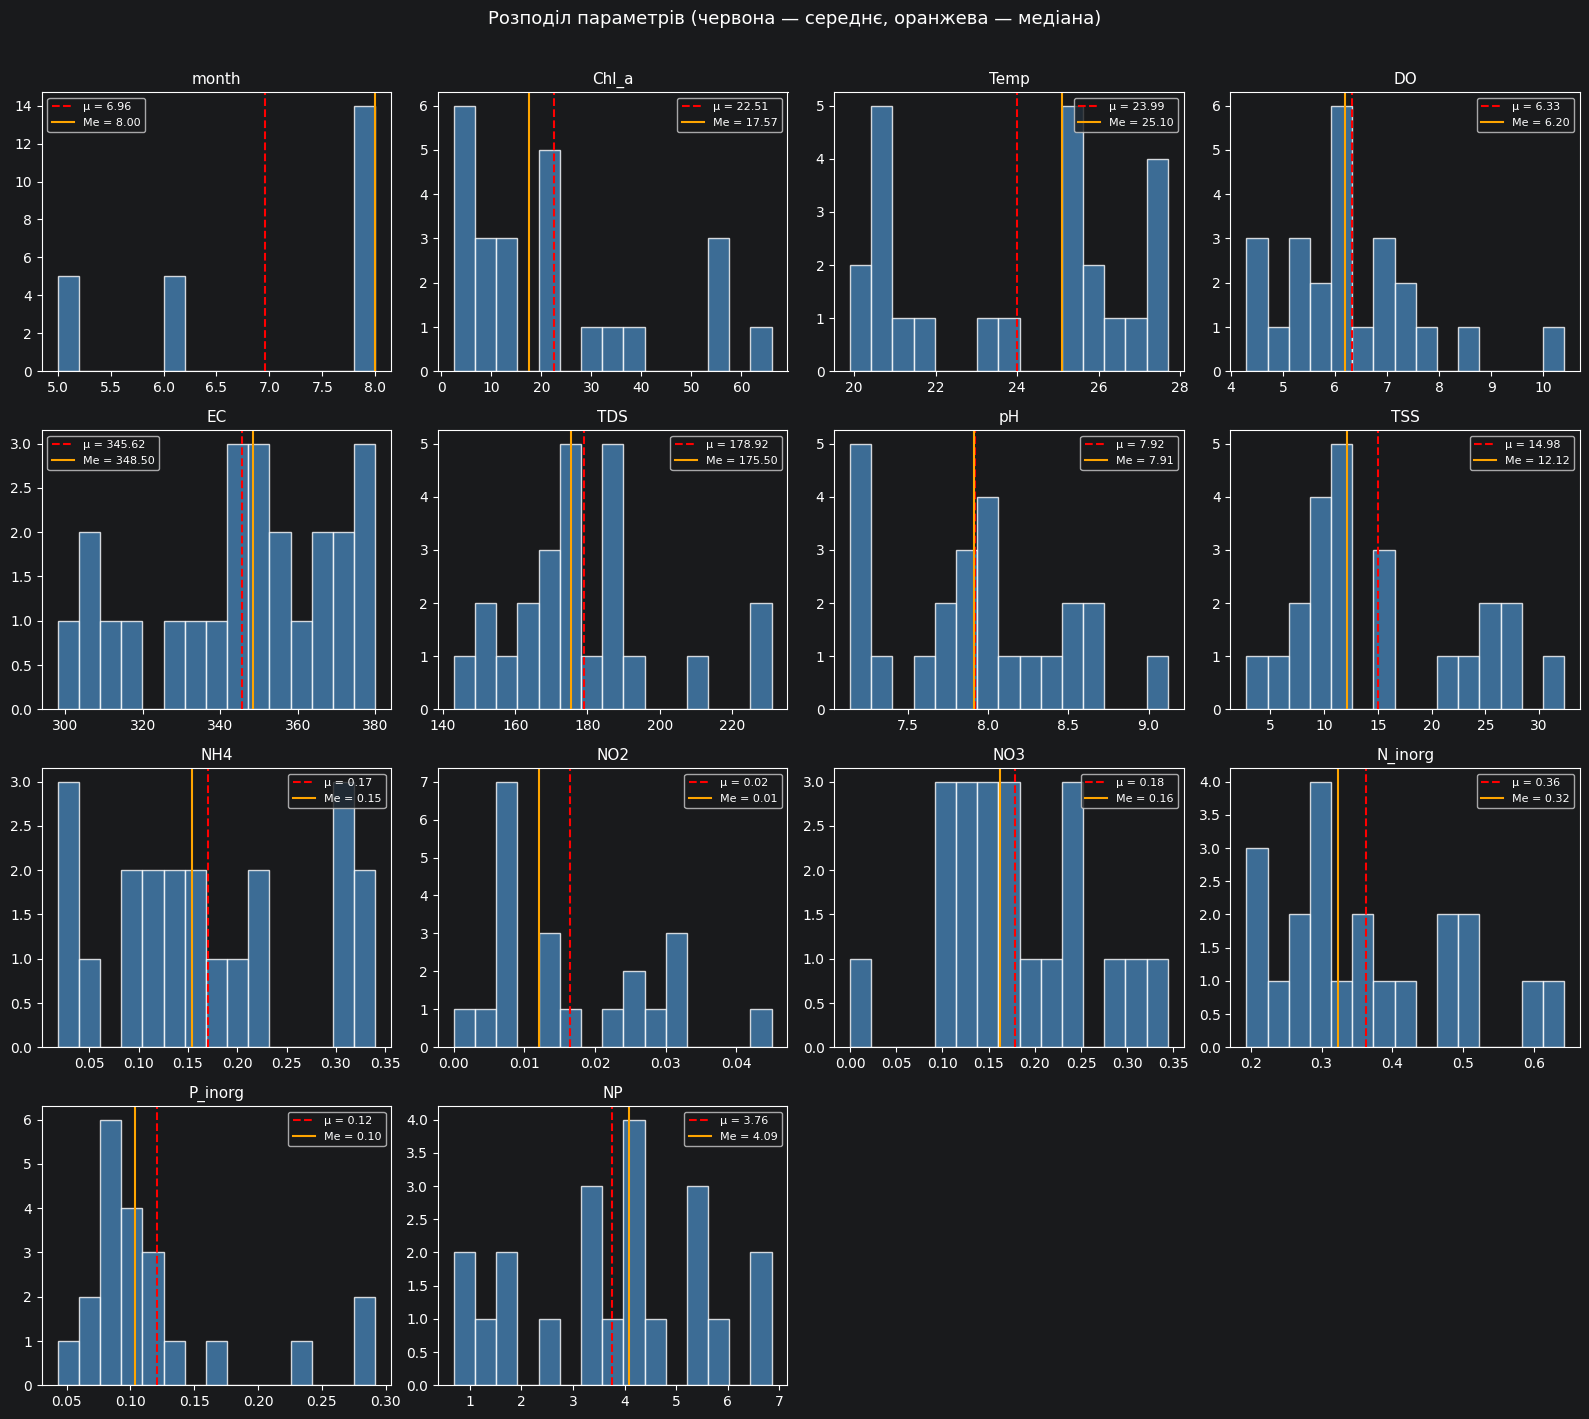

In [6]:
# === Описова статистика числових параметрів ===
desc = df[numeric_cols].describe().T
desc['missing'] = df[numeric_cols].isnull().sum()
desc['missing_%'] = (desc['missing'] / len(df) * 100).round(1)

print('Описова статистика числових параметрів:')
display(desc.style.format({
    'count': '{:.0f}', 'mean': '{:.3f}', 'std': '{:.3f}',
    'min': '{:.3f}', '25%': '{:.3f}', '50%': '{:.3f}',
    '75%': '{:.3f}', 'max': '{:.3f}',
    'missing': '{:.0f}', 'missing_%': '{:.1f}%',
}).set_caption('Базові статистики та кількість пропусків'))

# Гістограми розподілу
n_params = len(numeric_cols)
n_cols_plot = 4
n_rows_plot = (n_params + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 3.5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ = {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Me = {data.median():.2f}')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Розподіл параметрів (червона — середнє, оранжева — медіана)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Аналіз пропущених значень

Для оцінки структури пропусків побудовано бінарну матрицю (1 — пропуск, 0 — значення присутнє), візуалізовану як теплову карту (heatmap). Це дозволяє виявити закономірності у розташуванні пропусків — зокрема, чи пропуски зосереджені в окремих рядках (спостереженнях) або колонках (параметрах), що є важливим для вибору стратегії відновлення.

### Припущення щодо механізму пропусків (MAR)

Регресійна відновлення базується на припущенні **MAR** (*Missing At Random*) — ймовірність пропуску залежить від інших спостережуваних змінних, але не від самого пропущеного значення. Це припущення є обґрунтованим для гідрохімічних даних, оскільки:

- Пропуски виникають переважно через **технічні причини** (поломка приладу, недостатній об'єм проби, обмеження лабораторних методів), а не через екстремальні значення самого параметра.
- Пропуски спостерігаються **в окремих параметрах**, тоді як інші змінні для того ж спостереження наявні — це характерна ознака MAR.
- Пропуски **не систематичні** — вони не зосереджені виключно при високих або низьких значеннях інших параметрів.

Якщо б пропуски залежали від самого пропущеного значення (MNAR — *Missing Not At Random*), регресійне відновлення давала б зміщені оцінки, і потрібні були б складніші методи.

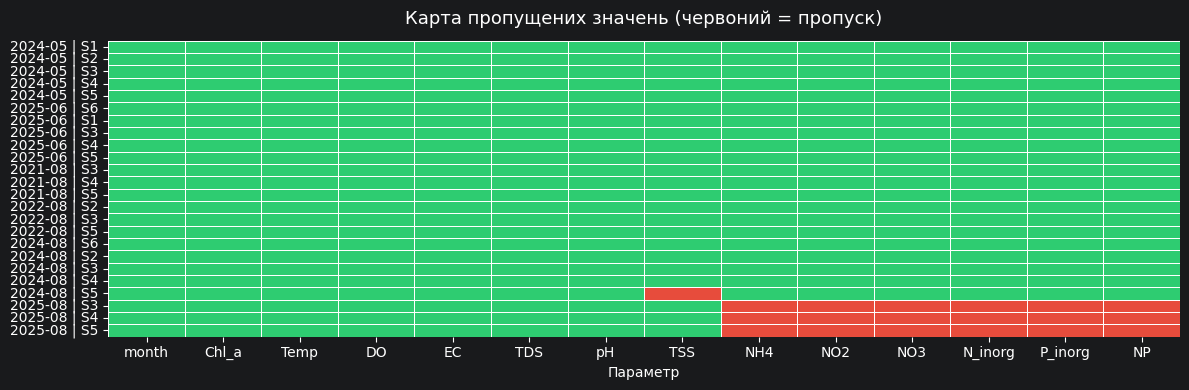

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
missing_matrix = df[numeric_cols].isnull().astype(int)

sns.heatmap(missing_matrix, cmap=['#2ecc71','#e74c3c'], cbar=False,
            yticklabels=[f"{row['year']}-{row['month']:02d} | {row['station']}" for _, row in df.iterrows()],
            ax=ax, linewidths=0.5)
ax.set_title('Карта пропущених значень (червоний = пропуск)', fontsize=13, pad=12)
ax.set_xlabel('Параметр')
plt.tight_layout()
plt.show()

## 5. Кореляційний аналіз

**Метод:** коефіцієнт кореляції Пірсона (Pearson's *r*).

Коефіцієнт Пірсона вимірює лінійну залежність між двома змінними і набуває значень від -1 (повна обернена залежність) до +1 (повна пряма залежність). Аналіз проводиться на повних спостереженнях (без пропусків), щоб уникнути зміщення оцінок.

Результати візуалізуються у вигляді трикутної матриці кореляцій (нижній трикутник), де кольорова шкала відображає напрям та силу зв'язку (зелений — позитивна кореляція, червоний — негативна). На основі цієї матриці обираються предиктори для регресійних моделей відновлення — параметри з найвищими абсолютними значеннями *r* щодо цільової змінної.

Повних рядків для навчання моделей: 20


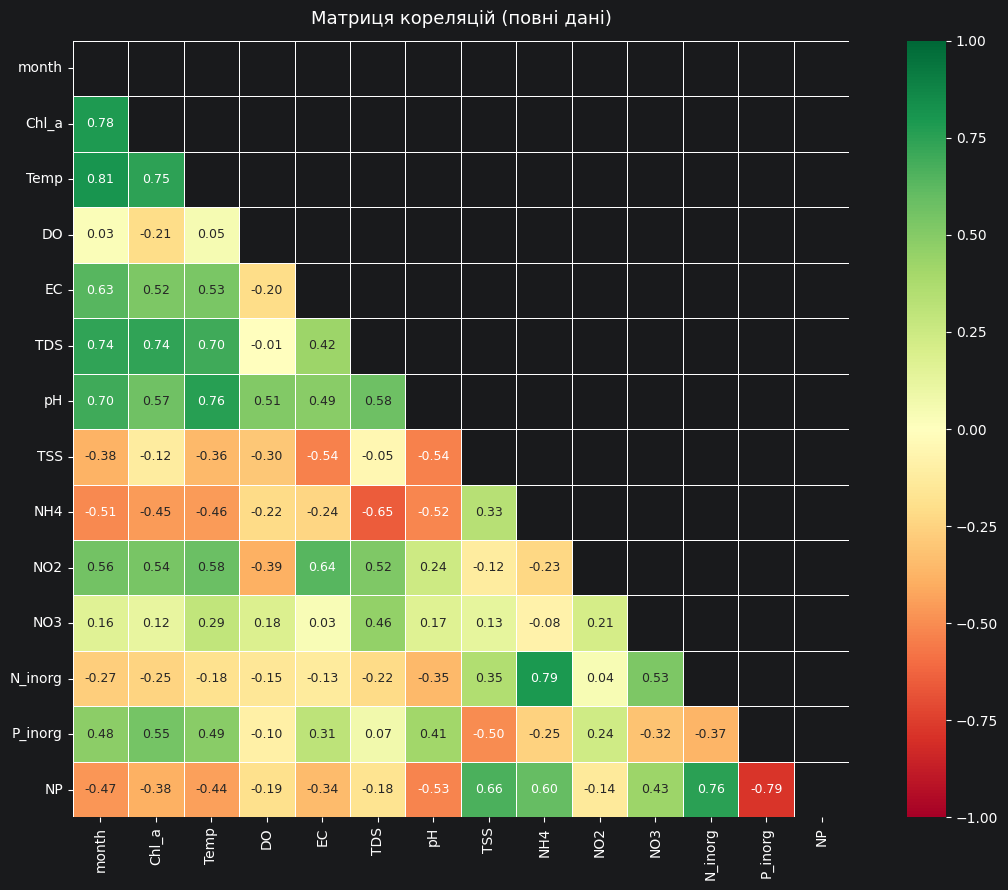

In [8]:
complete = df.dropna()
print(f'Повних рядків для навчання моделей: {len(complete)}')

corr = complete[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Матриця кореляцій (повні дані)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 6. Автоматичний вибір предикторів та побудова моделей

### 6.1. Відбір предикторів

Для кожного цільового параметра автоматично обираються предиктори з кореляцією Пірсона $|r| \geq$ порогу (`correlation_threshold`). Якщо предикторів за порогом менше ніж `min_predictors` — обираються топ-N за абсолютною кореляцією. Формульні параметри (`N_inorg`, `NP`) та інші цільові параметри виключаються зі списку предикторів для уникнення витоку даних.

### 6.2. Навчання та крос-валідація

Процес побудови моделей складається з **двох окремих етапів**, які важливо розрізняти:

**Етап 1 — Крос-валідація (оцінка якості).** Для кожної моделі виконується 5-fold CV: дані 5 разів поділяються на тренувальну (80%) та тестову (20%) частини, модель навчається і оцінюється. Результат — метрики CV R² та CV MAE, які дають незміщену оцінку узагальнюючої здатності моделі. **Ці 5 тимчасових моделей після оцінки не зберігаються** — вони потрібні виключно для порівняння підходів.

**Етап 2 — Фінальне навчання (для відновлення).** Після того як за результатами CV обрано найкращу модель, вона навчається **повторно на всіх 100% повних спостережень**. Саме ця фінальна модель використовується для заповнення пропусків у секції 7. Навчання на повному обсязі даних дозволяє максимально використати наявну інформацію.

```
Етап 1: Крос-валідація (тільки оцінка, моделі не зберігаються)
   Фолд 1: навчання на 80% → тест на 20% → R²₁  ┐
   Фолд 2: навчання на 80% → тест на 20% → R²₂  │→ CV R² = середнє
   Фолд 3: навчання на 80% → тест на 20% → R²₃  │  (5 тимчасових моделей
   Фолд 4: навчання на 80% → тест на 20% → R²₄  │   викидаються)
   Фолд 5: навчання на 80% → тест на 20% → R²₅  ┘

Етап 2: Вибір найкращої моделі за CV R²

Етап 3: Фінальне навчання обраної моделі на 100% даних → відновлення
```

### 6.3. Автоматичний вибір найкращої моделі

Для кожного параметра обирається модель з **найвищим CV R²** — це модель, яка найкраще узагальнює на нових даних. Після вибору вона навчається на повній вибірці та застосовується для прогнозування пропущених значень.

In [9]:
# === Автоматичний вибір предикторів на основі кореляції ===
threshold = CONFIG['correlation_threshold']
min_pred = CONFIG['min_predictors']
targets = CONFIG['targets']
exclude = set(CONFIG['exclude_as_predictors'] + targets)

# Доступні предиктори — всі числові, крім targets та формульних
available_predictors = [c for c in numeric_cols if c not in exclude]

regression_config = {}
print(f'Поріг кореляції: |r| ≥ {threshold}')
print(f'Доступні предиктори: {available_predictors}\n')

for target in targets:
    # Кореляції target з доступними предикторами
    target_corr = corr.loc[available_predictors, target].abs().sort_values(ascending=False)

    # Відбір за порогом
    selected = target_corr[target_corr >= threshold].index.tolist()

    # Якщо менше мінімуму — беремо топ-N
    if len(selected) < min_pred:
        selected = target_corr.head(min_pred).index.tolist()

    regression_config[target] = selected
    corr_vals = ', '.join(f'{p} ({corr.loc[p, target]:+.2f})' for p in selected)
    print(f'{target}: {corr_vals}')

print(f'\n{"=" * 70}')

# === Навчання моделей та cross-validation ===
enabled_models = [name for name, on in CONFIG['models'].items() if on]
cv_folds = CONFIG['cv_folds']

# Зберігатимемо: results[target][model_name] = {model, r2_train, mae_train, r2_cv, mae_cv}
all_results = {}
comparison_rows = []

for target, predictors in regression_config.items():
    train = complete[predictors + [target]].dropna()
    X = train[predictors].values
    y = train[target].values

    # Обмежуємо кількість фолдів розміром вибірки (для LOO-CV або малих вибірок)
    actual_cv = min(cv_folds, len(X))

    all_results[target] = {}

    for model_name in enabled_models:
        model = MODEL_REGISTRY[model_name]()
        model.fit(X, y)
        y_pred = model.predict(X)

        r2_train = r2_score(y, y_pred)
        mae_train = mean_absolute_error(y, y_pred)

        # Cross-validation (якщо вибірка достатня для хоча б 2 фолдів)
        if actual_cv >= 2:
            cv_r2 = cross_val_score(MODEL_REGISTRY[model_name](), X, y,
                                     cv=actual_cv, scoring='r2')
            cv_mae = cross_val_score(MODEL_REGISTRY[model_name](), X, y,
                                      cv=actual_cv, scoring='neg_mean_absolute_error')
            r2_cv = np.nanmean(cv_r2) if not np.all(np.isnan(cv_r2)) else r2_train
            mae_cv = -np.nanmean(cv_mae) if not np.all(np.isnan(cv_mae)) else mae_train
        else:
            r2_cv = r2_train
            mae_cv = mae_train

        all_results[target][model_name] = {
            'model': model, 'predictors': predictors,
            'r2_train': r2_train, 'mae_train': mae_train,
            'r2_cv': r2_cv, 'mae_cv': mae_cv,
        }

        comparison_rows.append({
            'Параметр': target, 'Модель': model_name,
            'R² (train)': r2_train, 'MAE (train)': mae_train,
            'R² (CV)': r2_cv, 'MAE (CV)': mae_cv,
        })

# === Зведена таблиця порівняння (окремо для кожного параметра) ===
comparison_df = pd.DataFrame(comparison_rows)

for target in targets:
    target_df = comparison_df[comparison_df['Параметр'] == target].copy()
    target_df = target_df.drop(columns=['Параметр']).reset_index(drop=True)
    
    # Знаходимо найкращу модель за CV R² (fallback на train R² якщо всі CV — NaN)
    if target_df['R² (CV)'].notna().any():
        best_idx = target_df['R² (CV)'].idxmax()
    else:
        best_idx = target_df['R² (train)'].idxmax()
    
    def highlight_best(row):
        if row.name == best_idx:
            return ['background-color: #2E7D32; color: white; font-weight: bold'] * len(row)
        return [''] * len(row)
    
    predictors = regression_config[target]
    print(f'\n{"=" * 70}')
    print(f'  {target} | Предиктори: {", ".join(predictors)}')
    print(f'{"=" * 70}')
    
    display(target_df.style
        .format({
            'R² (train)': '{:.3f}', 'MAE (train)': '{:.4f}',
            'R² (CV)': '{:.3f}', 'MAE (CV)': '{:.4f}',
        })
        .apply(highlight_best, axis=1)
    )

# === Вибір найкращої моделі для кожного target ===
best_models = {}
print('\n' + '=' * 70)
print('НАЙКРАЩІ МОДЕЛІ (за CV R²):')
print('=' * 70)

for target in targets:
    best_name = max(all_results[target],
                    key=lambda m: all_results[target][m]['r2_cv'])
    best = all_results[target][best_name]
    best_models[target] = {
        'model': best['model'],
        'model_name': best_name,
        'predictors': best['predictors'],
        'r2_train': best['r2_train'],
        'r2_cv': best['r2_cv'],
        'mae_cv': best['mae_cv'],
    }
    print(f'  {target:<10} → {best_name:<22} CV R²={best["r2_cv"]:.3f}  '
          f'CV MAE={best["mae_cv"]:.4f}  (train R²={best["r2_train"]:.3f})')

Поріг кореляції: |r| ≥ 0.5
Доступні предиктори: ['month', 'Chl_a', 'Temp', 'DO', 'EC', 'TDS', 'pH']

TSS: pH (-0.54), EC (-0.54)
NH4: TDS (-0.65), pH (-0.52), month (-0.51)
NO2: EC (+0.64), Temp (+0.58), month (+0.56), Chl_a (+0.54), TDS (+0.52)
NO3: TDS (+0.46), Temp (+0.29)
P_inorg: Chl_a (+0.55), Temp (+0.49)


  TSS | Предиктори: pH, EC


,Модель,R² (train),MAE (train),R² (CV),MAE (CV)
0,LinearRegression,0.389,5.0111,-0.655,5.9723
1,Ridge,0.386,5.0398,-0.613,6.0904
2,Lasso,0.389,5.0107,-0.654,5.9827
3,ElasticNet,0.389,5.0118,-0.650,5.9893
4,BayesianRidge,0.284,5.6547,-0.679,7.0145
5,RandomForest,0.849,2.6030,-1.028,7.4357
6,GradientBoosting,1.000,0.0685,-1.650,7.1306
7,ExtraTrees,1.000,0.0000,-1.222,7.8199
8,AdaBoost,0.968,0.9985,-1.235,7.0848
9,SVR,0.207,5.7722,-0.932,7.4495



  NH4 | Предиктори: TDS, pH, month


,Модель,R² (train),MAE (train),R² (CV),MAE (CV)
0,LinearRegression,0.456,0.0597,-2.116,0.0877
1,Ridge,0.454,0.0605,-1.919,0.0856
2,Lasso,0.422,0.0644,-1.656,0.0800
3,ElasticNet,0.443,0.0617,-1.753,0.0821
4,BayesianRidge,0.421,0.0640,-2.272,0.0875
5,RandomForest,0.934,0.0217,-6.836,0.0882
6,GradientBoosting,1.000,0.0008,-8.051,0.0809
7,ExtraTrees,1.000,0.0000,-8.631,0.0910
8,AdaBoost,0.983,0.0076,-8.474,0.0863
9,SVR,0.554,0.0601,-5.913,0.0977



  NO2 | Предиктори: EC, Temp, month, Chl_a, TDS


...


  NO3 | Предиктори: TDS, Temp


,Модель,R² (train),MAE (train),R² (CV),MAE (CV)
0,LinearRegression,0.212,0.0518,-1.419,0.0624
1,Ridge,0.212,0.0518,-1.409,0.0623
2,Lasso,0.210,0.0522,-1.269,0.0603
3,ElasticNet,0.211,0.0521,-1.368,0.0613
4,BayesianRidge,0.208,0.0521,-0.691,0.0560
5,RandomForest,0.803,0.0239,-1.873,0.0641
6,GradientBoosting,1.000,0.0011,-2.509,0.0682
7,ExtraTrees,1.000,0.0000,-2.093,0.0682
8,AdaBoost,0.968,0.0093,-3.600,0.0723
9,SVR,0.201,0.0574,-1.483,0.0626



  P_inorg | Предиктори: Chl_a, Temp


,Модель,R² (train),MAE (train),R² (CV),MAE (CV)
0,LinearRegression,0.317,0.0380,-3.695,0.0462
1,Ridge,0.317,0.0380,-3.661,0.0462
2,Lasso,0.313,0.0380,-3.069,0.0452
3,ElasticNet,0.316,0.0379,-3.320,0.0456
4,BayesianRidge,0.306,0.0384,-3.254,0.0449
5,RandomForest,0.846,0.0167,-5.647,0.0440
6,GradientBoosting,1.000,0.0002,-8.153,0.0471
7,ExtraTrees,1.000,0.0000,-8.822,0.0522
8,AdaBoost,0.975,0.0081,-10.409,0.0506
9,SVR,-0.311,0.0713,-38.613,0.0767



НАЙКРАЩІ МОДЕЛІ (за CV R²):
  TSS        → Ridge                  CV R²=-0.613  CV MAE=6.0904  (train R²=0.386)
  NH4        → Lasso                  CV R²=-1.656  CV MAE=0.0800  (train R²=0.422)
  NO2        → GradientBoosting       CV R²=-1.826  CV MAE=0.0090  (train R²=1.000)
  NO3        → BayesianRidge          CV R²=-0.691  CV MAE=0.0560  (train R²=0.208)
  P_inorg    → Lasso                  CV R²=-3.069  CV MAE=0.0452  (train R²=0.313)


### 6.4. Побудовані моделі: рівняння та структура

Після навчання кожна модель має конкретну математичну форму. Нижче для кожного цільового параметра та кожної моделі виведено:

- **Лінійні моделі** (OLS, Ridge, Lasso): повне рівняння $\hat{y} = \beta_0 + \beta_1 x_1 + \ldots + \beta_p x_p$ з числовими значеннями коефіцієнтів. Це дозволяє безпосередньо інтерпретувати внесок кожного предиктора.
- **Ансамблеві моделі** (Random Forest, Gradient Boosting): не мають єдиного рівняння, оскільки складаються з сотень дерев рішень. Замість цього наведено **важливість ознак** (*feature importance*) — відносний внесок кожного предиктора у прогноз.
- **SVR**: ядрова модель працює у трансформованому просторі ознак і не має явного рівняння. Наведено кількість опорних векторів та параметри ядра.

In [10]:
# === Побудовані моделі: рівняння та структура ===

for target, predictors in regression_config.items():
    print(f'\n{"=" * 80}')
    print(f'  ПАРАМЕТР: {target}')
    print(f'  Предиктори: {", ".join(predictors)}')
    print(f'{"=" * 80}')
    
    for model_name in enabled_models:
        res = all_results[target][model_name]
        model = res['model']
        is_best = (target in best_models and best_models[target]['model_name'] == model_name)
        marker = ' [НАЙКРАЩА]' if is_best else ''
        
        print(f'\n  --- {model_name}{marker} ---')
        
        if model_name in ('LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge'):
            # Лінійні моделі: виводимо рівняння
            intercept = model.intercept_
            coefs = model.coef_
            
            # Формуємо рівняння
            equation = f'  {target} = {intercept:.4f}'
            for p, c in zip(predictors, coefs):
                if c >= 0:
                    equation += f' + {c:.4f}*{p}'
                else:
                    equation += f' - {abs(c):.4f}*{p}'
            print(equation)
            
            # Таблиця коефіцієнтів
            print(f'\n  {"Предиктор":<15} {"Коефіцієнт":>14} {"Інтерпретація"}')
            print(f'  {"-" * 65}')
            print(f'  {"(intercept)":<15} {intercept:>14.4f}   Базове значення при всіх предикторах = 0')
            for p, c in zip(predictors, coefs):
                direction = 'збільшує' if c > 0 else 'зменшує'
                print(f'  {p:<15} {c:>14.4f}   {direction} {target} на {abs(c):.4f} при зростанні {p} на 1')
            
            # Для Lasso/ElasticNet — показати обнулені коефіцієнти
            if model_name in ('Lasso', 'ElasticNet'):
                zero_coefs = [p for p, c in zip(predictors, coefs) if abs(c) < 1e-10]
                if zero_coefs:
                    print(f'\n  {model_name} обнулила коефіцієнти: {", ".join(zero_coefs)} (ці предиктори виключені моделлю)')
                else:
                    print(f'\n  {model_name} залишила всі предиктори (жоден коефіцієнт не обнулений)')
        
        elif model_name in ('RandomForest', 'GradientBoosting', 'ExtraTrees', 'AdaBoost'):
            # Ансамблеві моделі: важливість ознак
            importances = model.feature_importances_
            n_estimators = model.n_estimators
            
            print(f'  Кількість дерев: {n_estimators}')
            print(f'\n  {"Предиктор":<15} {"Важливість":>12} {"Відносний внесок"}')
            print(f'  {"-" * 55}')
            
            sorted_idx = np.argsort(importances)[::-1]
            for idx in sorted_idx:
                bar = '█' * int(importances[idx] * 30)
                print(f'  {predictors[idx]:<15} {importances[idx]:>12.4f}   {bar}')
        
        elif model_name == 'SVR':
            # SVR: параметри Pipeline (scaler + svr)
            svr_model = model.named_steps['svr']
            scaler = model.named_steps['scaler']
            
            print(f'  Ядро (kernel): {svr_model.kernel}')
            print(f'  Параметр C: {svr_model.C}')
            print(f'  Параметр epsilon: {svr_model.epsilon}')
            print(f'  Параметр gamma: {svr_model.gamma}')
            print(f'  Кількість опорних векторів: {svr_model.n_support_}')
            print(f'\n  Масштабування (StandardScaler):')
            print(f'  {"Предиктор":<15} {"Середнє (μ)":>12} {"Ст. відх. (σ)":>14}')
            print(f'  {"-" * 45}')
            for p, m, s in zip(predictors, scaler.mean_, scaler.scale_):
                print(f'  {p:<15} {m:>12.4f} {s:>14.4f}')
            print(f'\n  Модель працює з нормалізованими ознаками: x\' = (x - μ) / σ')
        
        elif model_name == 'KNN':
            # KNN: параметри Pipeline (scaler + knn)
            knn_model = model.named_steps['knn']
            scaler = model.named_steps['scaler']
            
            print(f'  Кількість сусідів (k): {knn_model.n_neighbors}')
            print(f'  Метрика відстані: {knn_model.metric}')
            print(f'  Ваги сусідів: {knn_model.weights}')
            print(f'\n  Масштабування (StandardScaler):')
            print(f'  {"Предиктор":<15} {"Середнє (μ)":>12} {"Ст. відх. (σ)":>14}')
            print(f'  {"-" * 45}')
            for p, m, s in zip(predictors, scaler.mean_, scaler.scale_):
                print(f'  {p:<15} {m:>12.4f} {s:>14.4f}')
            print(f'\n  Модель працює з нормалізованими ознаками: x\' = (x - μ) / σ')
            print(f'  Прогноз = середнє значень {knn_model.n_neighbors} найближчих сусідів')

print(f'\n{"=" * 80}')
print('Примітка: для лінійних моделей рівняння можна використовувати безпосередньо.')
print('Ансамблеві та ядрові моделі не мають явної формули — прогноз обчислюється алгоритмічно.')


  ПАРАМЕТР: TSS
  Предиктори: pH, EC

  --- LinearRegression ---
  TSS = 103.6318 - 5.5521*pH - 0.1290*EC

  Предиктор           Коефіцієнт Інтерпретація
  -----------------------------------------------------------------
  (intercept)           103.6318   Базове значення при всіх предикторах = 0
  pH                     -5.5521   зменшує TSS на 5.5521 при зростанні pH на 1
  EC                     -0.1290   зменшує TSS на 0.1290 при зростанні EC на 1

  --- Ridge [НАЙКРАЩА] ---
  TSS = 99.5569 - 4.5490*pH - 0.1404*EC

  Предиктор           Коефіцієнт Інтерпретація
  -----------------------------------------------------------------
  (intercept)            99.5569   Базове значення при всіх предикторах = 0
  pH                     -4.5490   зменшує TSS на 4.5490 при зростанні pH на 1
  EC                     -0.1404   зменшує TSS на 0.1404 при зростанні EC на 1

  --- Lasso ---
  TSS = 103.4490 - 5.5086*pH - 0.1295*EC

  Предиктор           Коефіцієнт Інтерпретація
  -----------------

### 6.5. Аналіз результатів навчання

Таблиця вище містить порівняння всіх моделей за двома метриками: **R² (train)** — якість на навчальних даних, та **R² (CV)** — якість на крос-валідації. Ключові спостереження:

- **R² (train) ≈ 1.0** при значно нижчому **R² (CV)** свідчить про **перенавчання** — модель запам'ятовує тренувальні дані замість виявлення закономірностей. Це характерно для складних моделей (Random Forest, Gradient Boosting) на малих вибірках.
- **Лінійні моделі** (OLS, Ridge, Lasso) зазвичай мають близькі значення train та CV R², що вказує на стабільність та відсутність перенавчання.
- **Від'ємний CV R²** означає, що модель прогнозує гірше за просте середнє — це сигнал про непридатність моделі для даного параметра.

### 6.5.1. Візуальне порівняння моделей

Для кожного цільового параметра побудовано два стовпчикових графіки:

- **CV R² (ліворуч):** коефіцієнт детермінації на крос-валідації. **Чим вище стовпчик — тим краще** модель. Значення R² = 1 — ідеальний прогноз, R² = 0 — модель не краща за середнє, R² < 0 — модель прогнозує гірше за середнє.
- **CV MAE (праворуч):** середня абсолютна помилка на крос-валідації. **Чим нижче стовпчик — тим краще** модель, оскільки менша помилка означає точніший прогноз.

Найкраща модель для кожного параметра позначена зірочкою (**★**) на графіку CV R².

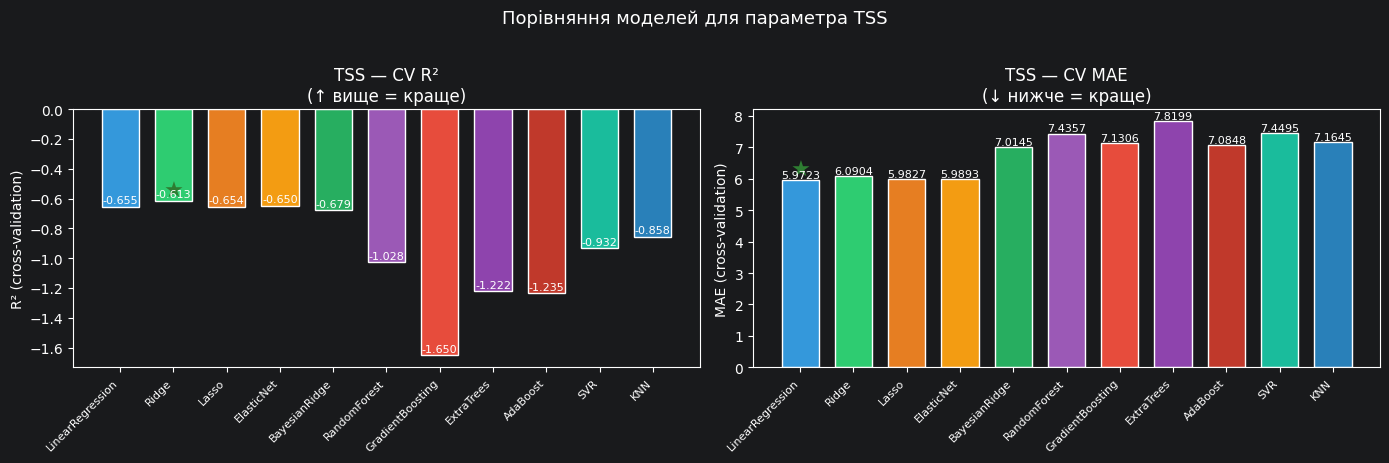

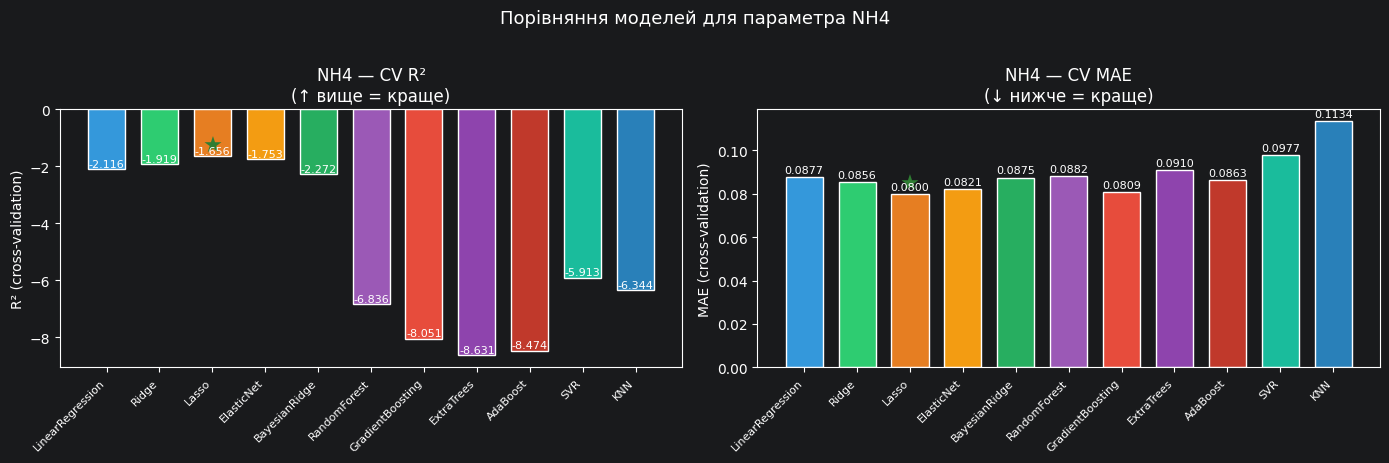

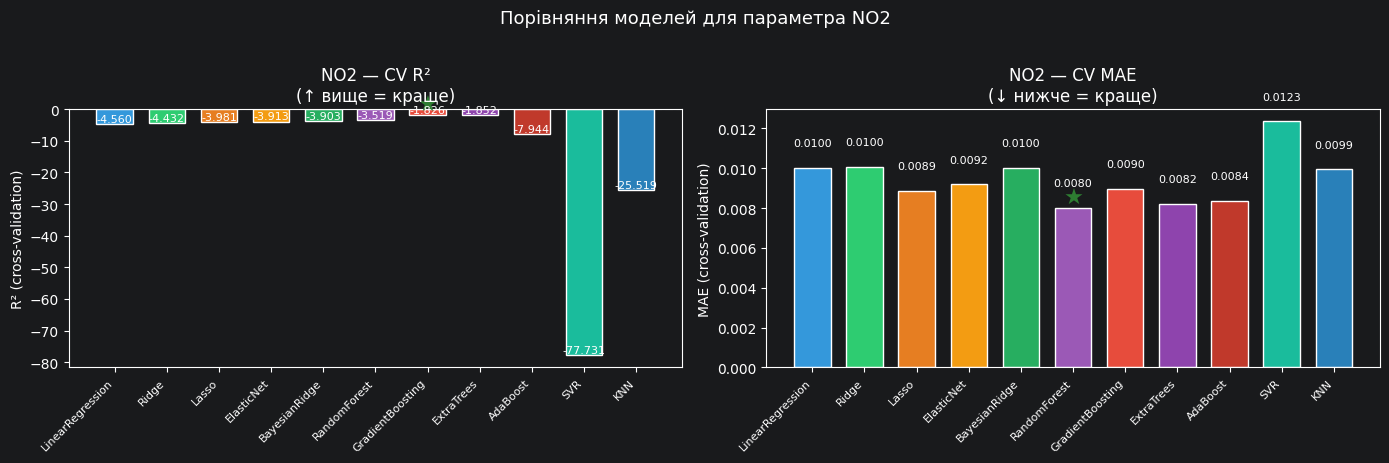

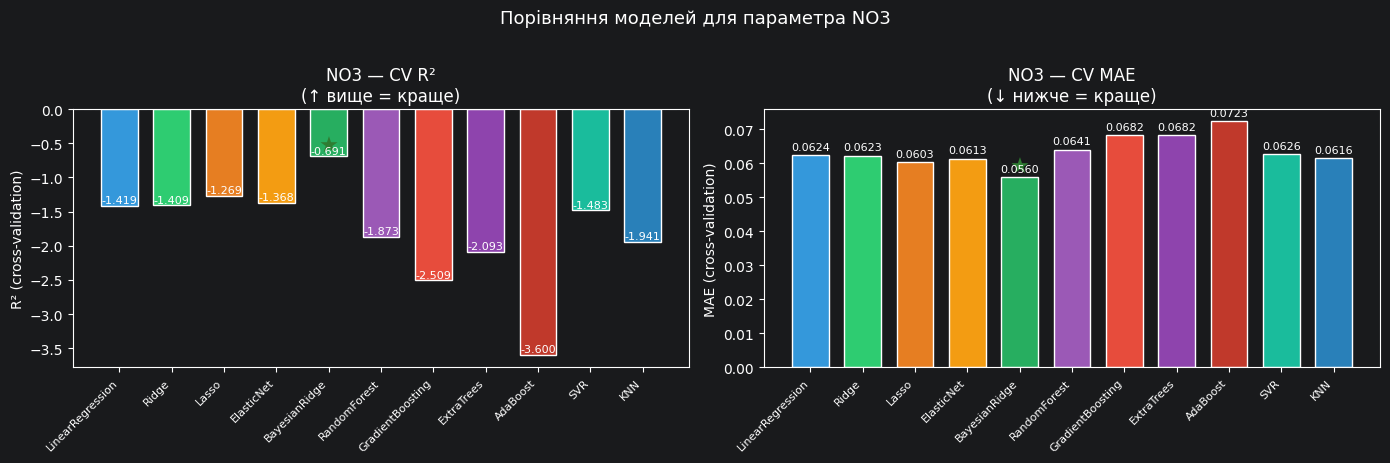

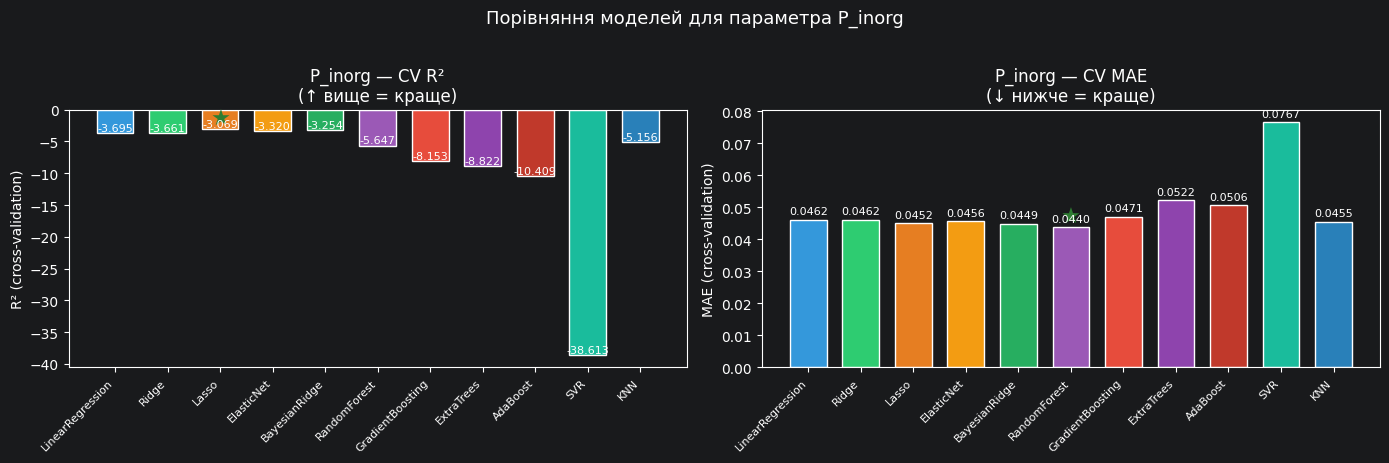

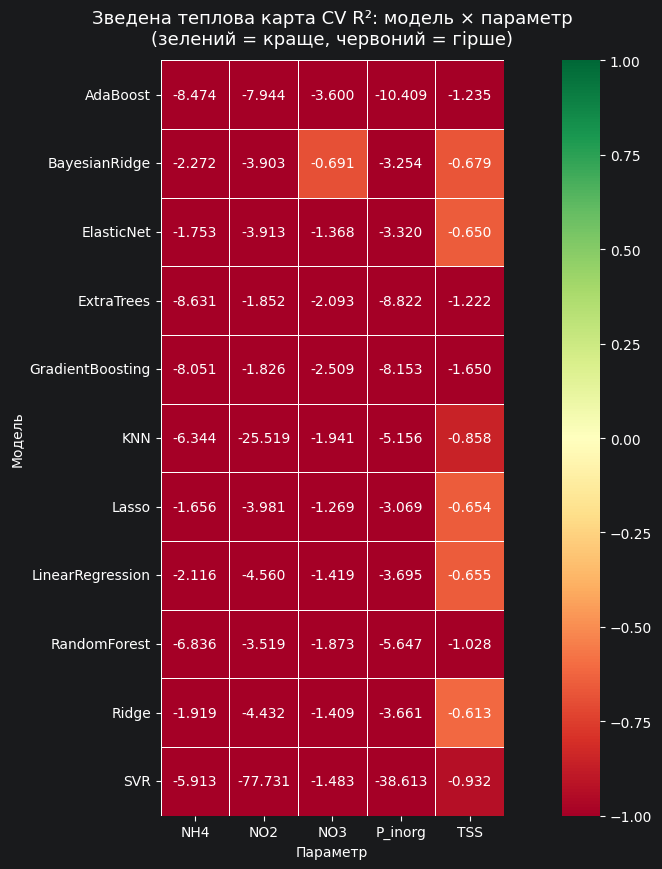

In [11]:
# === Візуалізація порівняння моделей (окремо для кожного параметра) ===
if len(enabled_models) > 1:
    pivot_r2 = comparison_df.pivot(index='Параметр', columns='Модель', values='R² (CV)')
    pivot_mae = comparison_df.pivot(index='Параметр', columns='Модель', values='MAE (CV)')
    
    colors_map = {'LinearRegression': '#3498db', 'Ridge': '#2ecc71', 'Lasso': '#e67e22',
                  'ElasticNet': '#f39c12', 'BayesianRidge': '#27ae60',
                  'RandomForest': '#9b59b6', 'GradientBoosting': '#e74c3c',
                  'ExtraTrees': '#8e44ad', 'AdaBoost': '#c0392b',
                  'SVR': '#1abc9c', 'KNN': '#2980b9'}
    bar_colors = [colors_map.get(m, '#95a5a6') for m in enabled_models]
    
    for target in targets:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        
        # --- CV R² ---
        r2_vals = [all_results[target][m]['r2_cv'] for m in enabled_models]
        best_name = best_models[target]['model_name']
        best_idx_bar = enabled_models.index(best_name)
        
        bars = axes[0].bar(enabled_models, r2_vals, color=bar_colors, edgecolor='white', width=0.7)
        # Позначаємо найкращу зірочкою
        axes[0].annotate('★', xy=(best_idx_bar, r2_vals[best_idx_bar]),
                         ha='center', va='bottom', fontsize=16, color='#2E7D32', fontweight='bold')
        axes[0].set_title(f'{target} — CV R²\n(↑ вище = краще)', fontsize=12)
        axes[0].set_ylabel('R² (cross-validation)')
        axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        axes[0].set_xticklabels(enabled_models, rotation=45, ha='right', fontsize=8)
        # Значення на стовпчиках
        for bar, val in zip(bars, r2_vals):
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        
        # --- CV MAE ---
        mae_vals = [all_results[target][m]['mae_cv'] for m in enabled_models]
        best_mae_idx = mae_vals.index(min(mae_vals))
        
        bars = axes[1].bar(enabled_models, mae_vals, color=bar_colors, edgecolor='white', width=0.7)
        axes[1].annotate('★', xy=(best_mae_idx, mae_vals[best_mae_idx]),
                         ha='center', va='bottom', fontsize=16, color='#2E7D32', fontweight='bold')
        axes[1].set_title(f'{target} — CV MAE\n(↓ нижче = краще)', fontsize=12)
        axes[1].set_ylabel('MAE (cross-validation)')
        axes[1].set_xticklabels(enabled_models, rotation=45, ha='right', fontsize=8)
        for bar, val in zip(bars, mae_vals):
            axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                        f'{val:.4f}', ha='center', va='bottom', fontsize=8)
        
        fig.suptitle(f'Порівняння моделей для параметра {target}', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

    # Heatmap: CV R² (модель × target)
    fig, ax = plt.subplots(figsize=(12, max(3, len(enabled_models) * 0.8)))
    sns.heatmap(pivot_r2.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True)
    ax.set_title('Зведена теплова карта CV R²: модель × параметр\n(зелений = краще, червоний = гірше)',
                 fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()
else:
    print(f'Увімкнена лише одна модель ({enabled_models[0]}) — порівняння не потрібне.')

### 6.5.2. Факт vs Прогноз: найкраща модель для кожного параметра

Діаграми розсіювання (scatter plots) нижче відображають фактичні значення (вісь X) проти прогнозованих (вісь Y) для найкращої моделі кожного параметра. Чим ближче точки до червоної діагоналі (лінія ідеального прогнозу), тим точніша модель.

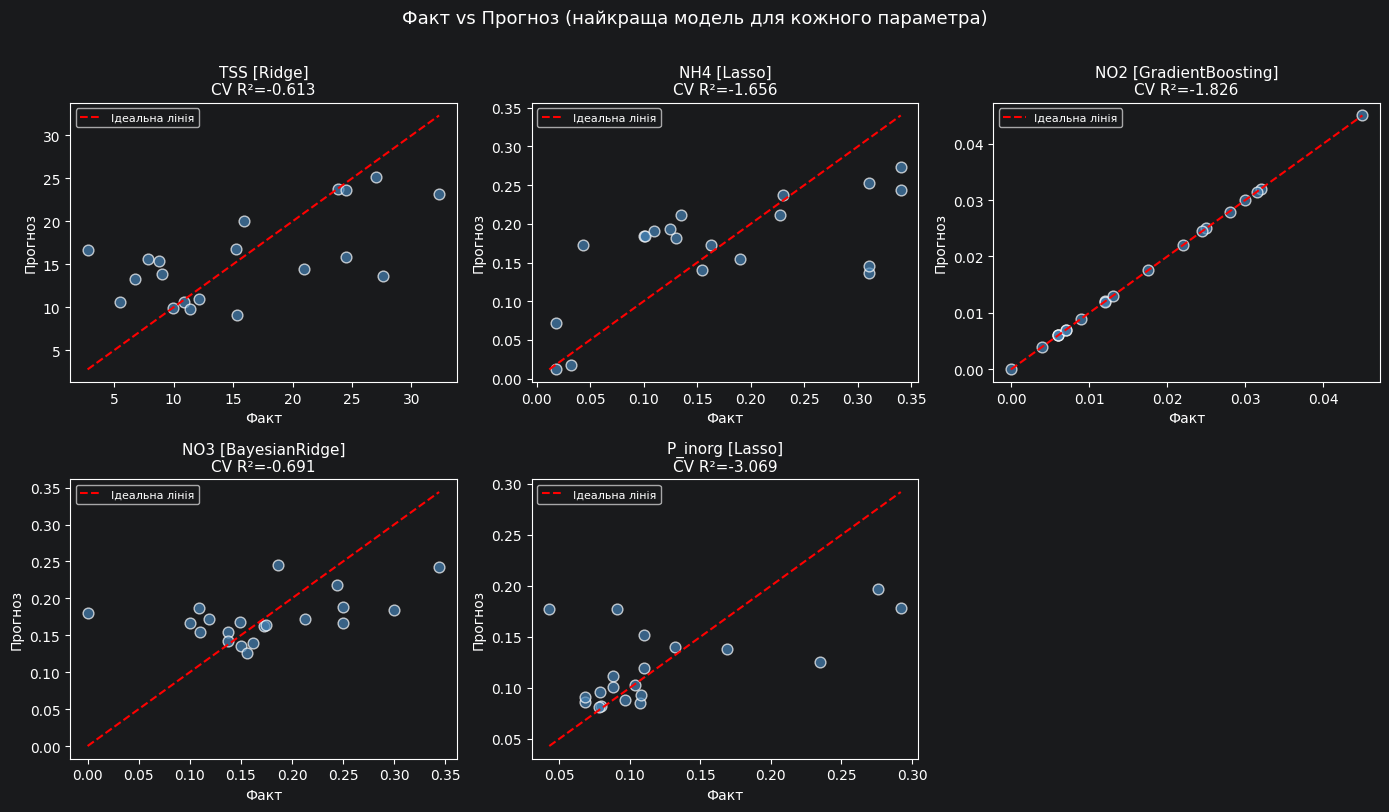

In [12]:
# Графіки: факт vs прогноз для найкращої моделі кожного параметра
n_targets = len(best_models)
n_cols = 3
n_rows = (n_targets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).flatten()

for i, (target, info) in enumerate(best_models.items()):
    train = complete[info['predictors'] + [target]].dropna()
    X = train[info['predictors']].values
    y_true = train[target].values
    y_pred = info['model'].predict(X)

    ax = axes[i]
    ax.scatter(y_true, y_pred, color='steelblue', alpha=0.7, edgecolors='white', s=60)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Ідеальна лінія')
    ax.set_title(f'{target} [{info["model_name"]}]\nCV R²={info["r2_cv"]:.3f}', fontsize=11)
    ax.set_xlabel('Факт')
    ax.set_ylabel('Прогноз')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Факт vs Прогноз (найкраща модель для кожного параметра)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6.6. Детальне порівняння: прогнози всіх моделей для кожного параметра

Для повного розуміння відмінностей між моделями, нижче для **кожного цільового параметра** наведено:
1. Прогнозовані значення для рядків з пропусками від **кожної моделі**
2. Метрики якості кожної моделі (CV R², CV MAE)
3. Позначення найкращої моделі

Це дозволяє наочно побачити:
- наскільки різні моделі дають **схожі або розбіжні** прогнози
- чому саме обрана модель є найкращою для конкретного параметра
- де моделі **одностайні** (всі дають близькі значення — висока впевненість) і де **розходяться** (великий розкид — низька впевненість)

In [13]:
# === Детальне порівняння прогнозів усіх моделей для кожного параметра ===

missing_idx = df[df.isnull().any(axis=1)].index.tolist()

for target, predictors in regression_config.items():
    best_name = best_models[target]['model_name'] if target in best_models else None
    
    print(f'\n{"=" * 70}')
    print(f'  {target} | Предиктори: {", ".join(predictors)}')
    print(f'{"=" * 70}')
    
    # --- Таблиця 1: Метрики якості моделей ---
    print(f'\n  Метрики якості моделей:')
    metrics_rows = []
    for model_name in enabled_models:
        res = all_results[target][model_name]
        metrics_rows.append({
            'Модель': model_name,
            'R² (train)': res['r2_train'],
            'R² (CV)': res['r2_cv'],
            'MAE (CV)': res['mae_cv'],
        })
    
    metrics_df = pd.DataFrame(metrics_rows)
    best_metrics_idx = metrics_df['R² (CV)'].idxmax()
    
    def highlight_best_metric(row):
        if row.name == best_metrics_idx:
            return ['background-color: #2E7D32; color: white; font-weight: bold'] * len(row)
        return [''] * len(row)
    
    display(metrics_df.style
        .format({'R² (train)': '{:.4f}', 'R² (CV)': '{:.4f}', 'MAE (CV)': '{:.4f}'})
        .apply(highlight_best_metric, axis=1)
        .set_caption(f'Порівняння моделей для {target} (найкраща підсвічена зеленим)')
    )
    
    # --- Таблиця 2: Прогнози для рядків з пропусками ---
    target_missing = [idx for idx in missing_idx if pd.isnull(df.loc[idx, target])]
    
    if target_missing:
        print(f'\n  Прогнози для рядків з пропусками ({target}):')
        
        pred_rows = []
        for idx in target_missing:
            row = df.loc[idx]
            row_label = f'{int(row["year"])}-{int(row["month"]):02d} ст.{row["station"]}'
            
            if not all(pd.notnull(df.loc[idx, p]) for p in predictors):
                row_data = {'Спостереження': row_label}
                for model_name in enabled_models:
                    row_data[model_name] = None
                row_data['Розкид'] = None
                pred_rows.append(row_data)
                continue
            
            X_new = np.array([[df.loc[idx, p] for p in predictors]])
            row_data = {'Спостереження': row_label}
            preds = []
            
            for model_name in enabled_models:
                pred = max(0, all_results[target][model_name]['model'].predict(X_new)[0])
                row_data[model_name] = pred
                preds.append(pred)
            
            row_data['Розкид'] = max(preds) - min(preds)
            pred_rows.append(row_data)
        
        pred_df = pd.DataFrame(pred_rows)
        
        # Підсвітка: колонка найкращої моделі — зеленим, найбільший розкид — червоним
        def highlight_predictions(col):
            styles = [''] * len(col)
            if col.name == best_name:
                styles = ['background-color: #2E7D32; color: white; font-weight: bold'] * len(col)
            return styles
        
        format_dict = {m: '{:.4f}' for m in enabled_models}
        format_dict['Розкид'] = '{:.4f}'
        
        display(pred_df.style
            .format(format_dict, na_rep='—')
            .apply(highlight_predictions, axis=0)
            .bar(subset=['Розкид'], color='#B71C1C', vmin=0)
            .set_caption(f'Прогнози всіх моделей для {target} (обрана модель — зеленим; розкид: довша червона смужка = більша розбіжність між моделями)')
        )
    else:
        print(f'  Пропусків для {target} не виявлено.')

print(f'\n{"=" * 70}')
print('Розкид — різниця між максимальним та мінімальним прогнозом серед усіх моделей.')
print('Малий розкид = моделі одностайні (висока впевненість).')
print('Великий розкид = результат залежить від вибору моделі (низька впевненість).')


  TSS | Предиктори: pH, EC

  Метрики якості моделей:


,Модель,R² (train),R² (CV),MAE (CV)
0,LinearRegression,0.3891,-0.6547,5.9723
1,Ridge,0.3858,-0.6132,6.0904
2,Lasso,0.3891,-0.6541,5.9827
3,ElasticNet,0.3890,-0.6498,5.9893
4,BayesianRidge,0.2842,-0.6789,7.0145
5,RandomForest,0.8493,-1.0277,7.4357
6,GradientBoosting,0.9999,-1.6502,7.1306
7,ExtraTrees,1.0000,-1.2218,7.8199
8,AdaBoost,0.9678,-1.2350,7.0848
9,SVR,0.2069,-0.9322,7.4495



  Прогнози для рядків з пропусками (TSS):


,Спостереження,LinearRegression,Ridge,Lasso,ElasticNet,BayesianRidge,RandomForest,GradientBoosting,ExtraTrees,AdaBoost,SVR,KNN,Розкид
0,2024-08 ст.S5,9.6912,9.4133,9.6798,9.6524,9.1148,11.6356,9.9797,12.0487,15.2900,11.2951,10.8380,6.1752



  NH4 | Предиктори: TDS, pH, month

  Метрики якості моделей:


...


  P_inorg | Предиктори: Chl_a, Temp

  Метрики якості моделей:


,Модель,R² (train),R² (CV),MAE (CV)
0,LinearRegression,0.3174,-3.6948,0.0462
1,Ridge,0.3174,-3.6612,0.0462
2,Lasso,0.3127,-3.0694,0.0452
3,ElasticNet,0.3162,-3.3205,0.0456
4,BayesianRidge,0.3055,-3.2545,0.0449
5,RandomForest,0.8457,-5.6474,0.0440
6,GradientBoosting,1.0000,-8.1525,0.0471
7,ExtraTrees,1.0000,-8.8224,0.0522
8,AdaBoost,0.9746,-10.4086,0.0506
9,SVR,-0.3114,-38.6128,0.0767



  Прогнози для рядків з пропусками (P_inorg):


,Спостереження,LinearRegression,Ridge,Lasso,ElasticNet,BayesianRidge,RandomForest,GradientBoosting,ExtraTrees,AdaBoost,SVR,KNN,Розкид
0,2025-08 ст.S3,0.1202,0.1202,0.1197,0.1199,0.1195,0.1260,0.1514,0.1543,0.1245,0.1620,0.1214,0.0424
1,2025-08 ст.S4,0.1271,0.1270,0.1226,0.1248,0.1205,0.1265,0.1499,0.1348,0.1205,0.1417,0.1468,0.0294
2,2025-08 ст.S5,0.1087,0.1086,0.1027,0.1057,0.1010,0.0970,0.0889,0.1263,0.0893,0.1660,0.1420,0.0771



Розкид — різниця між максимальним та мінімальним прогнозом серед усіх моделей.
Малий розкид = моделі одностайні (висока впевненість).
Великий розкид = результат залежить від вибору моделі (низька впевненість).


### 6.6.1. Факт vs Прогноз: усі моделі для кожного параметра

Нижче для кожного цільового параметра побудовано діаграми розсіювання для **всіх** моделей одночасно. Точки з золотою обводкою позначають найкращу модель. Це дозволяє візуально порівняти, як різні моделі апроксимують залежність.

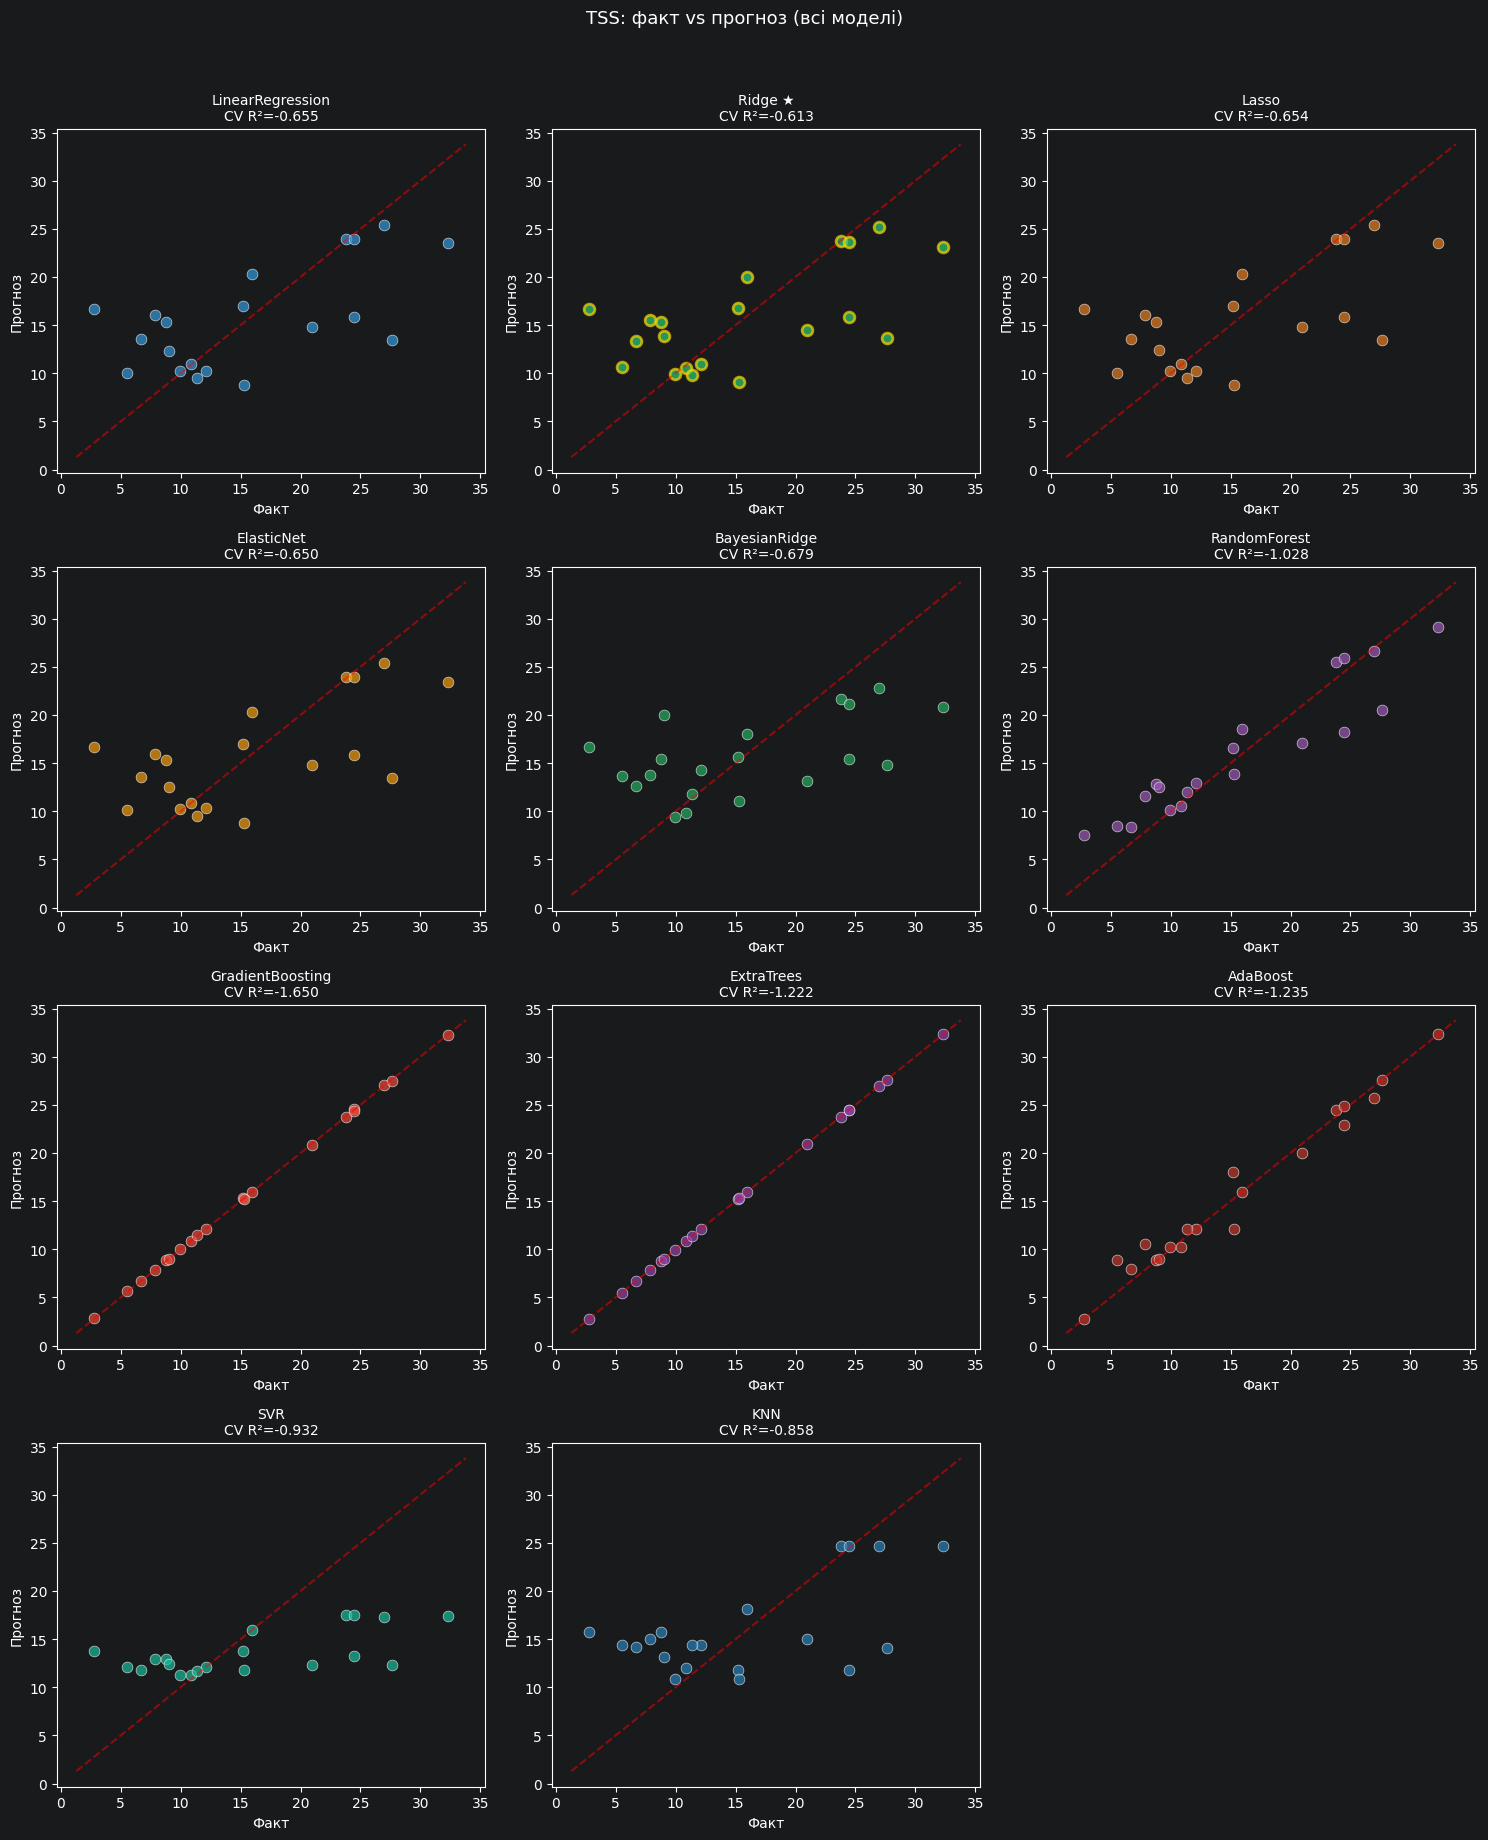

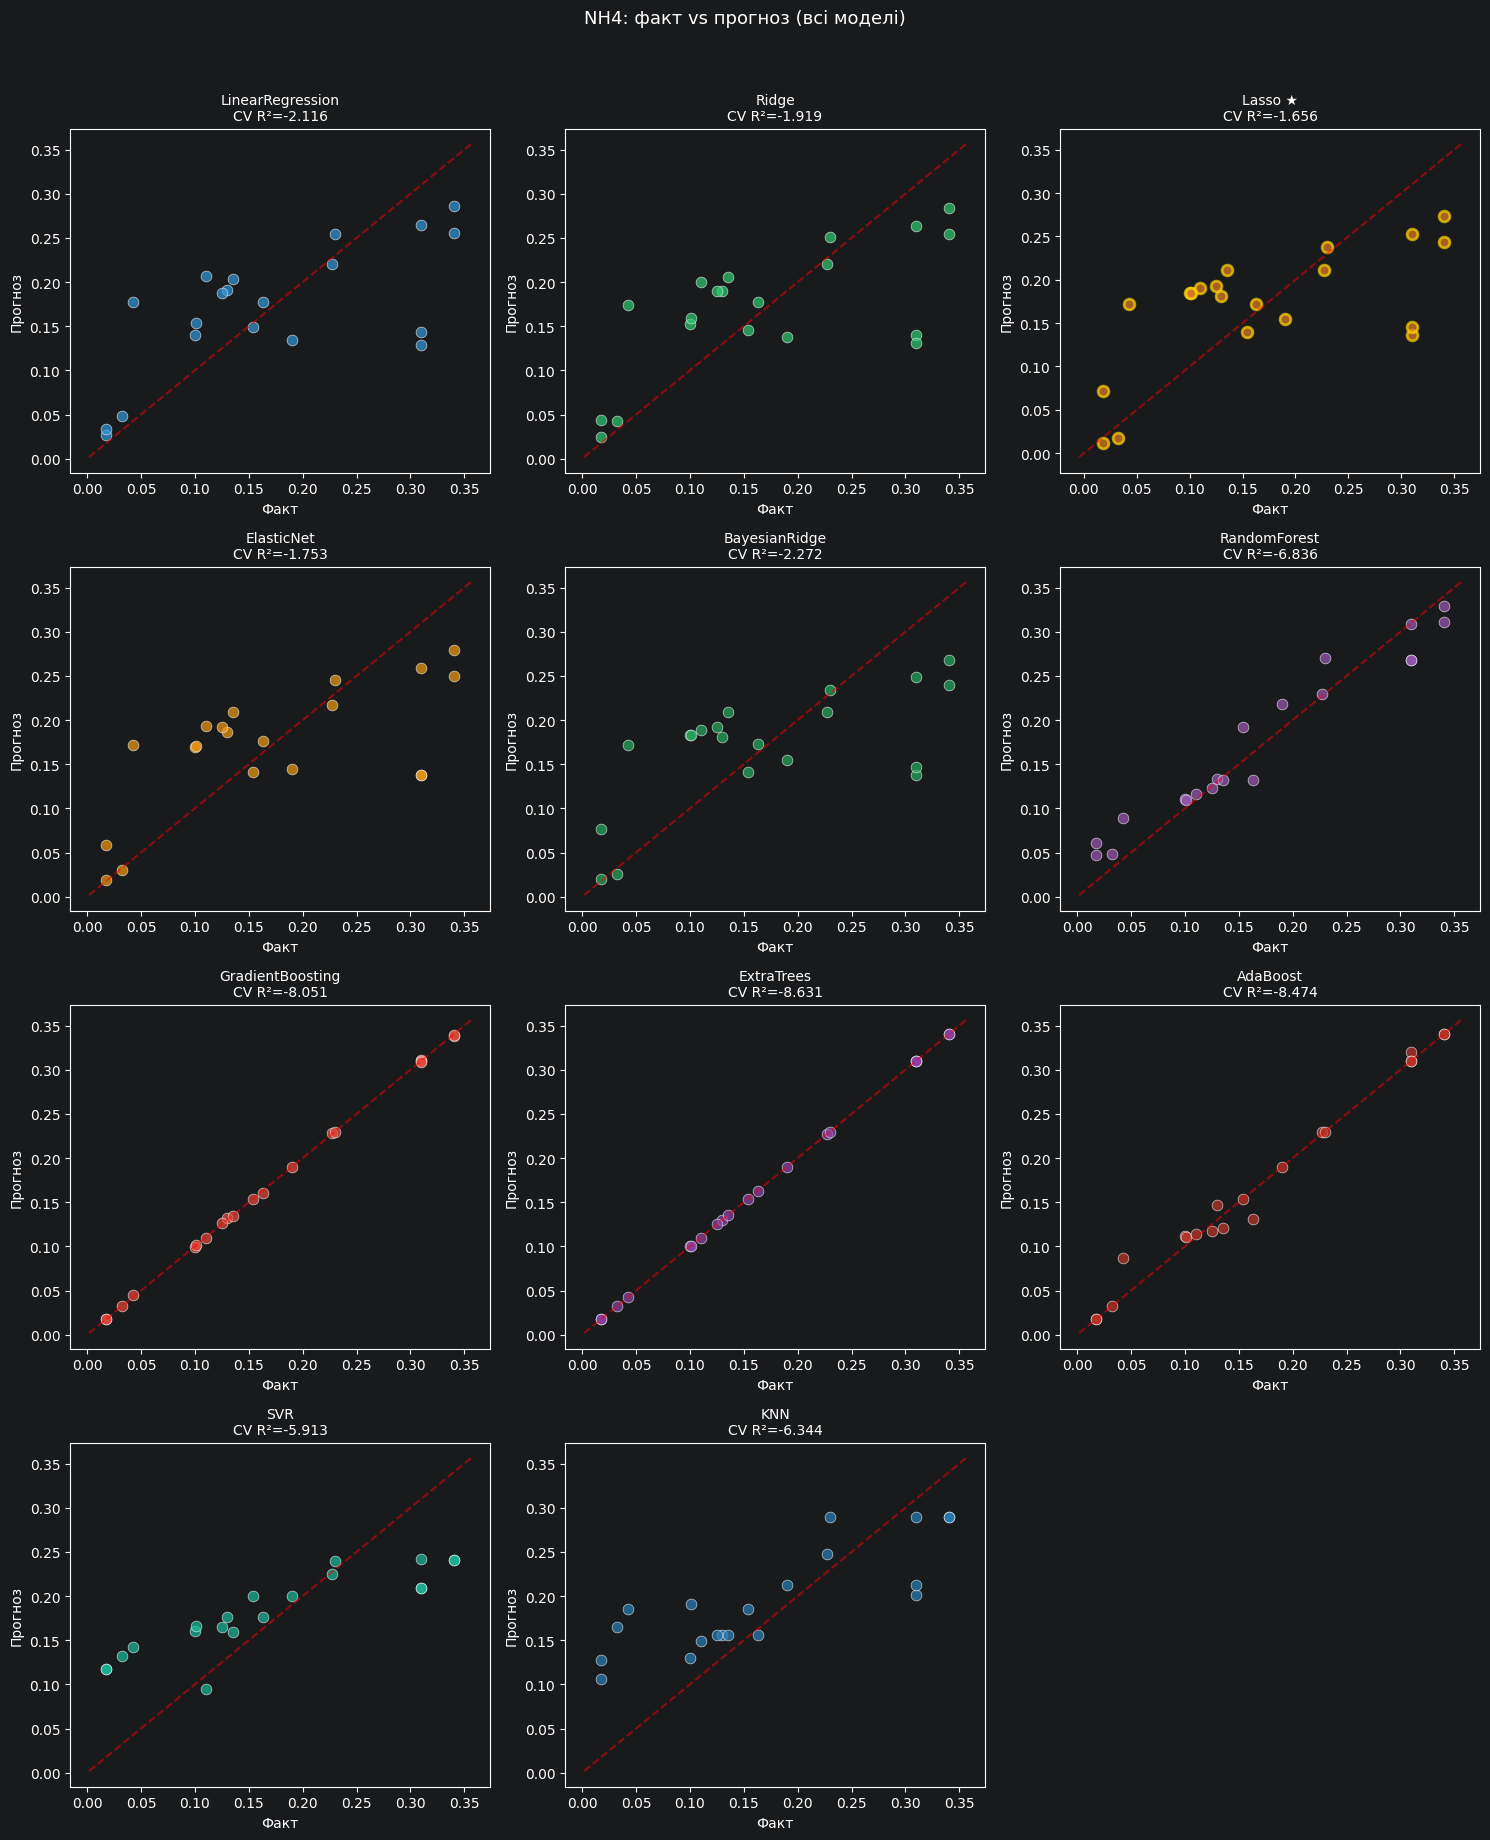

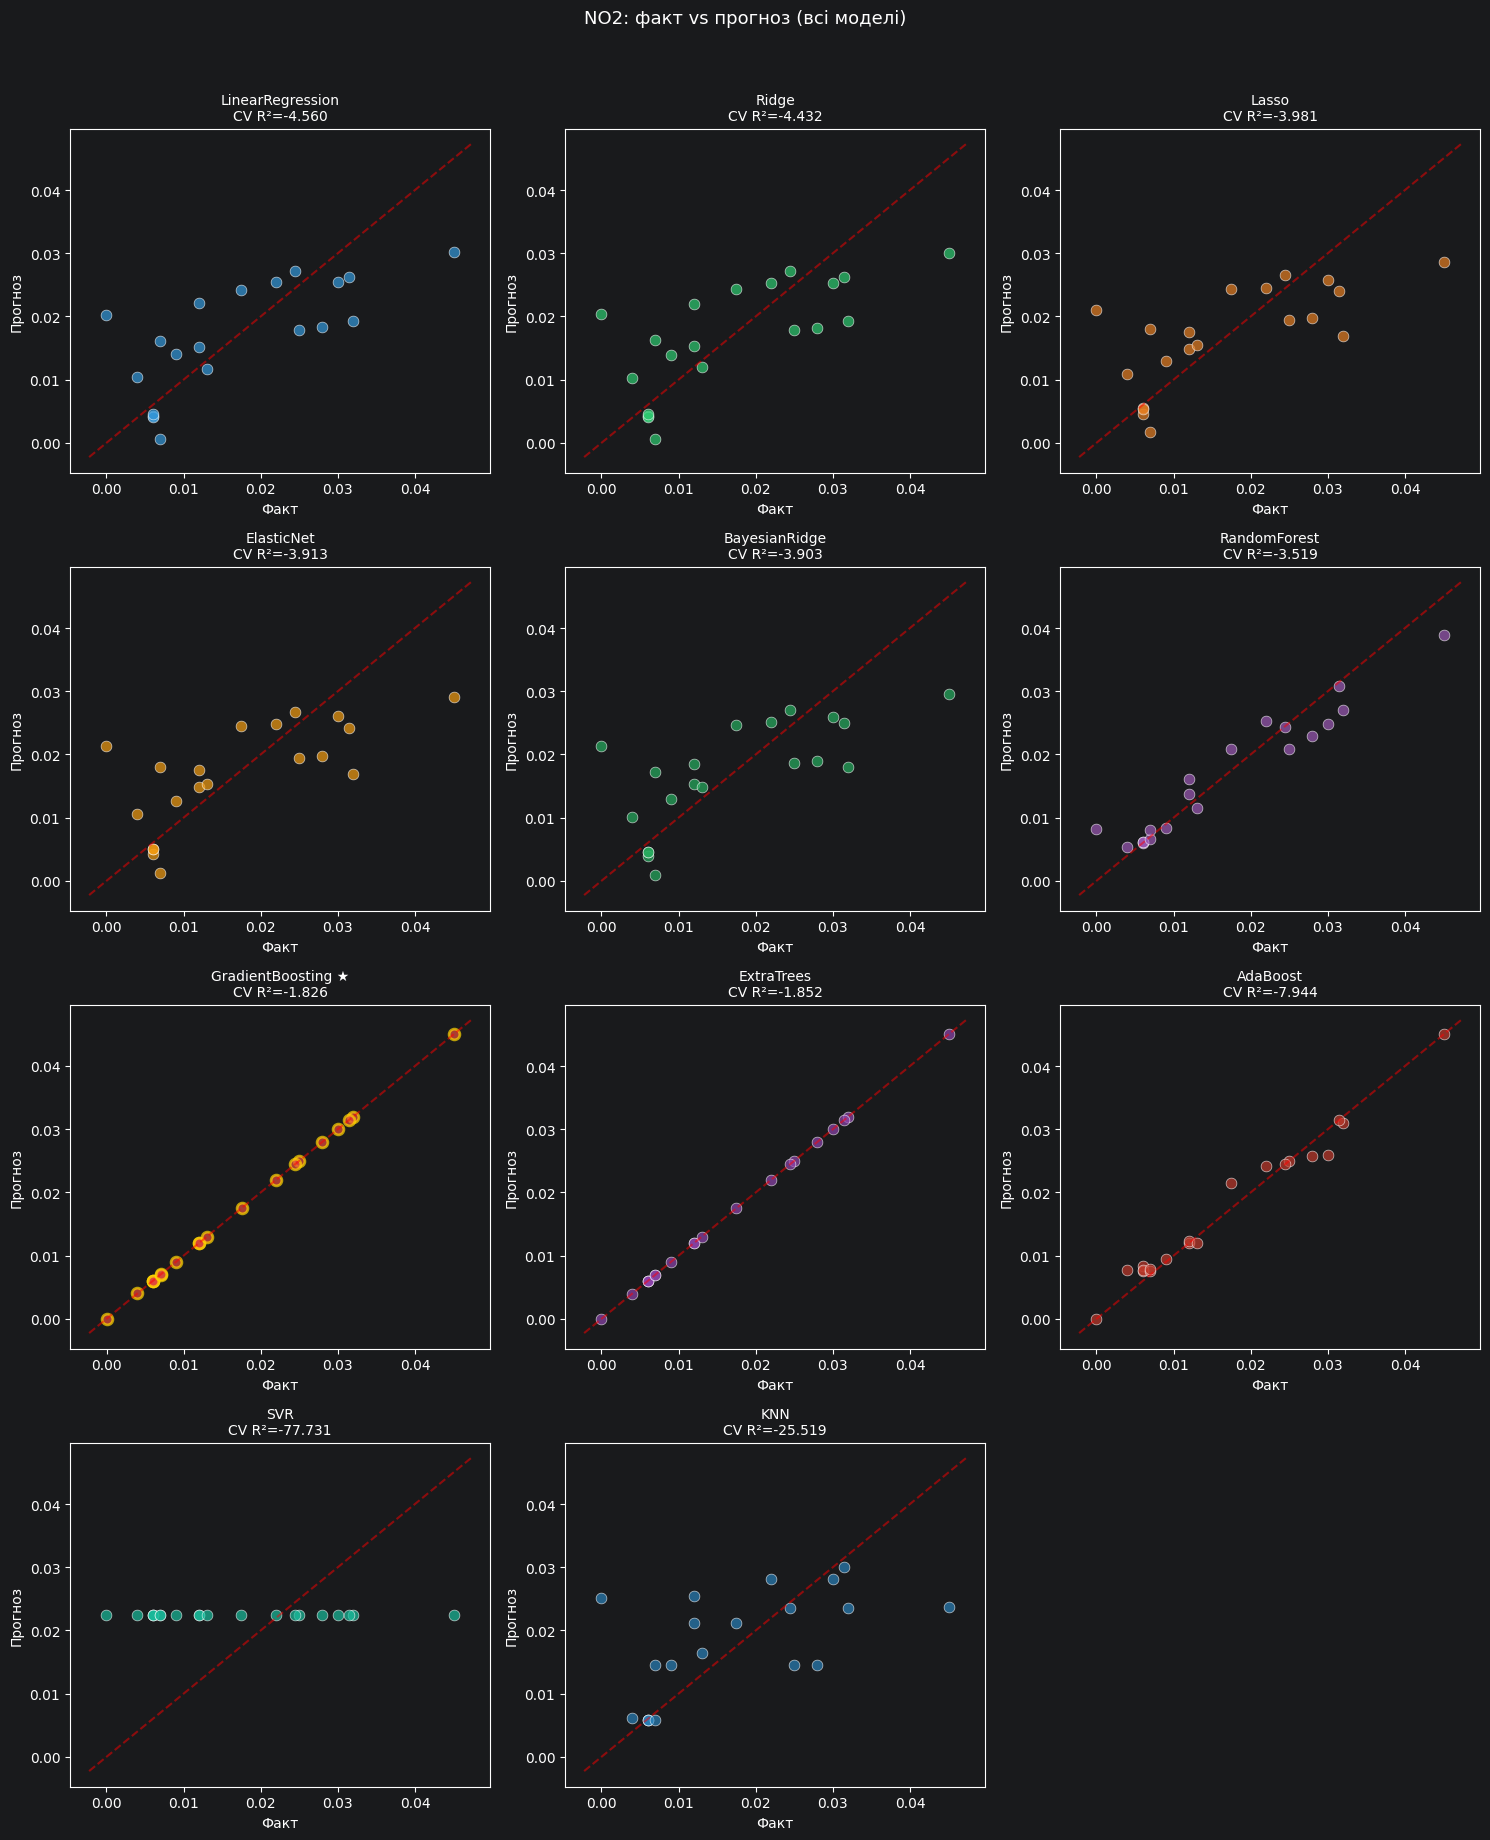

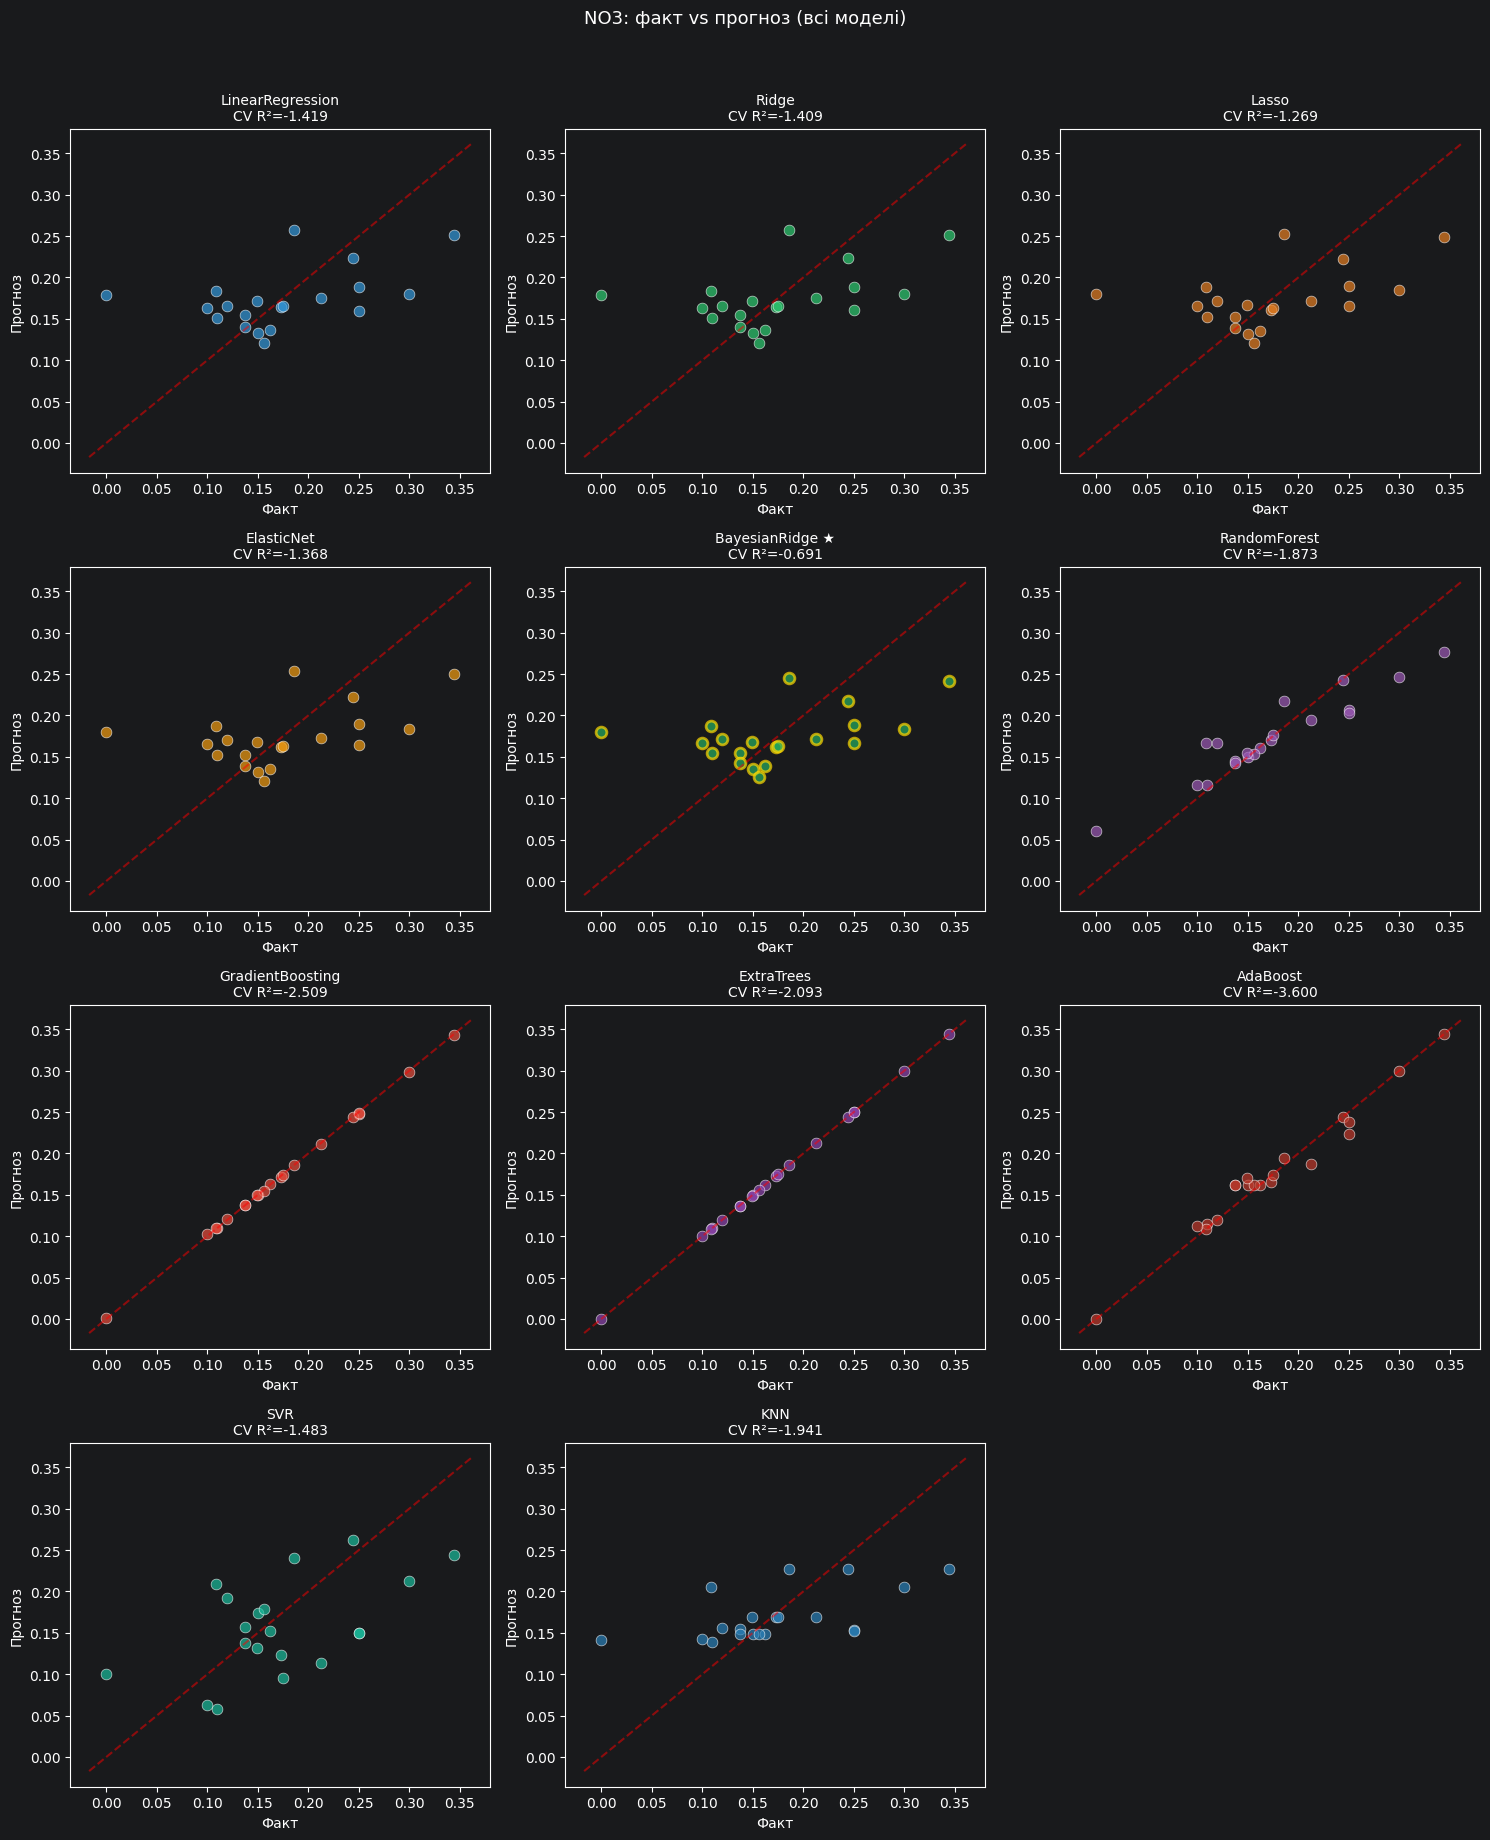

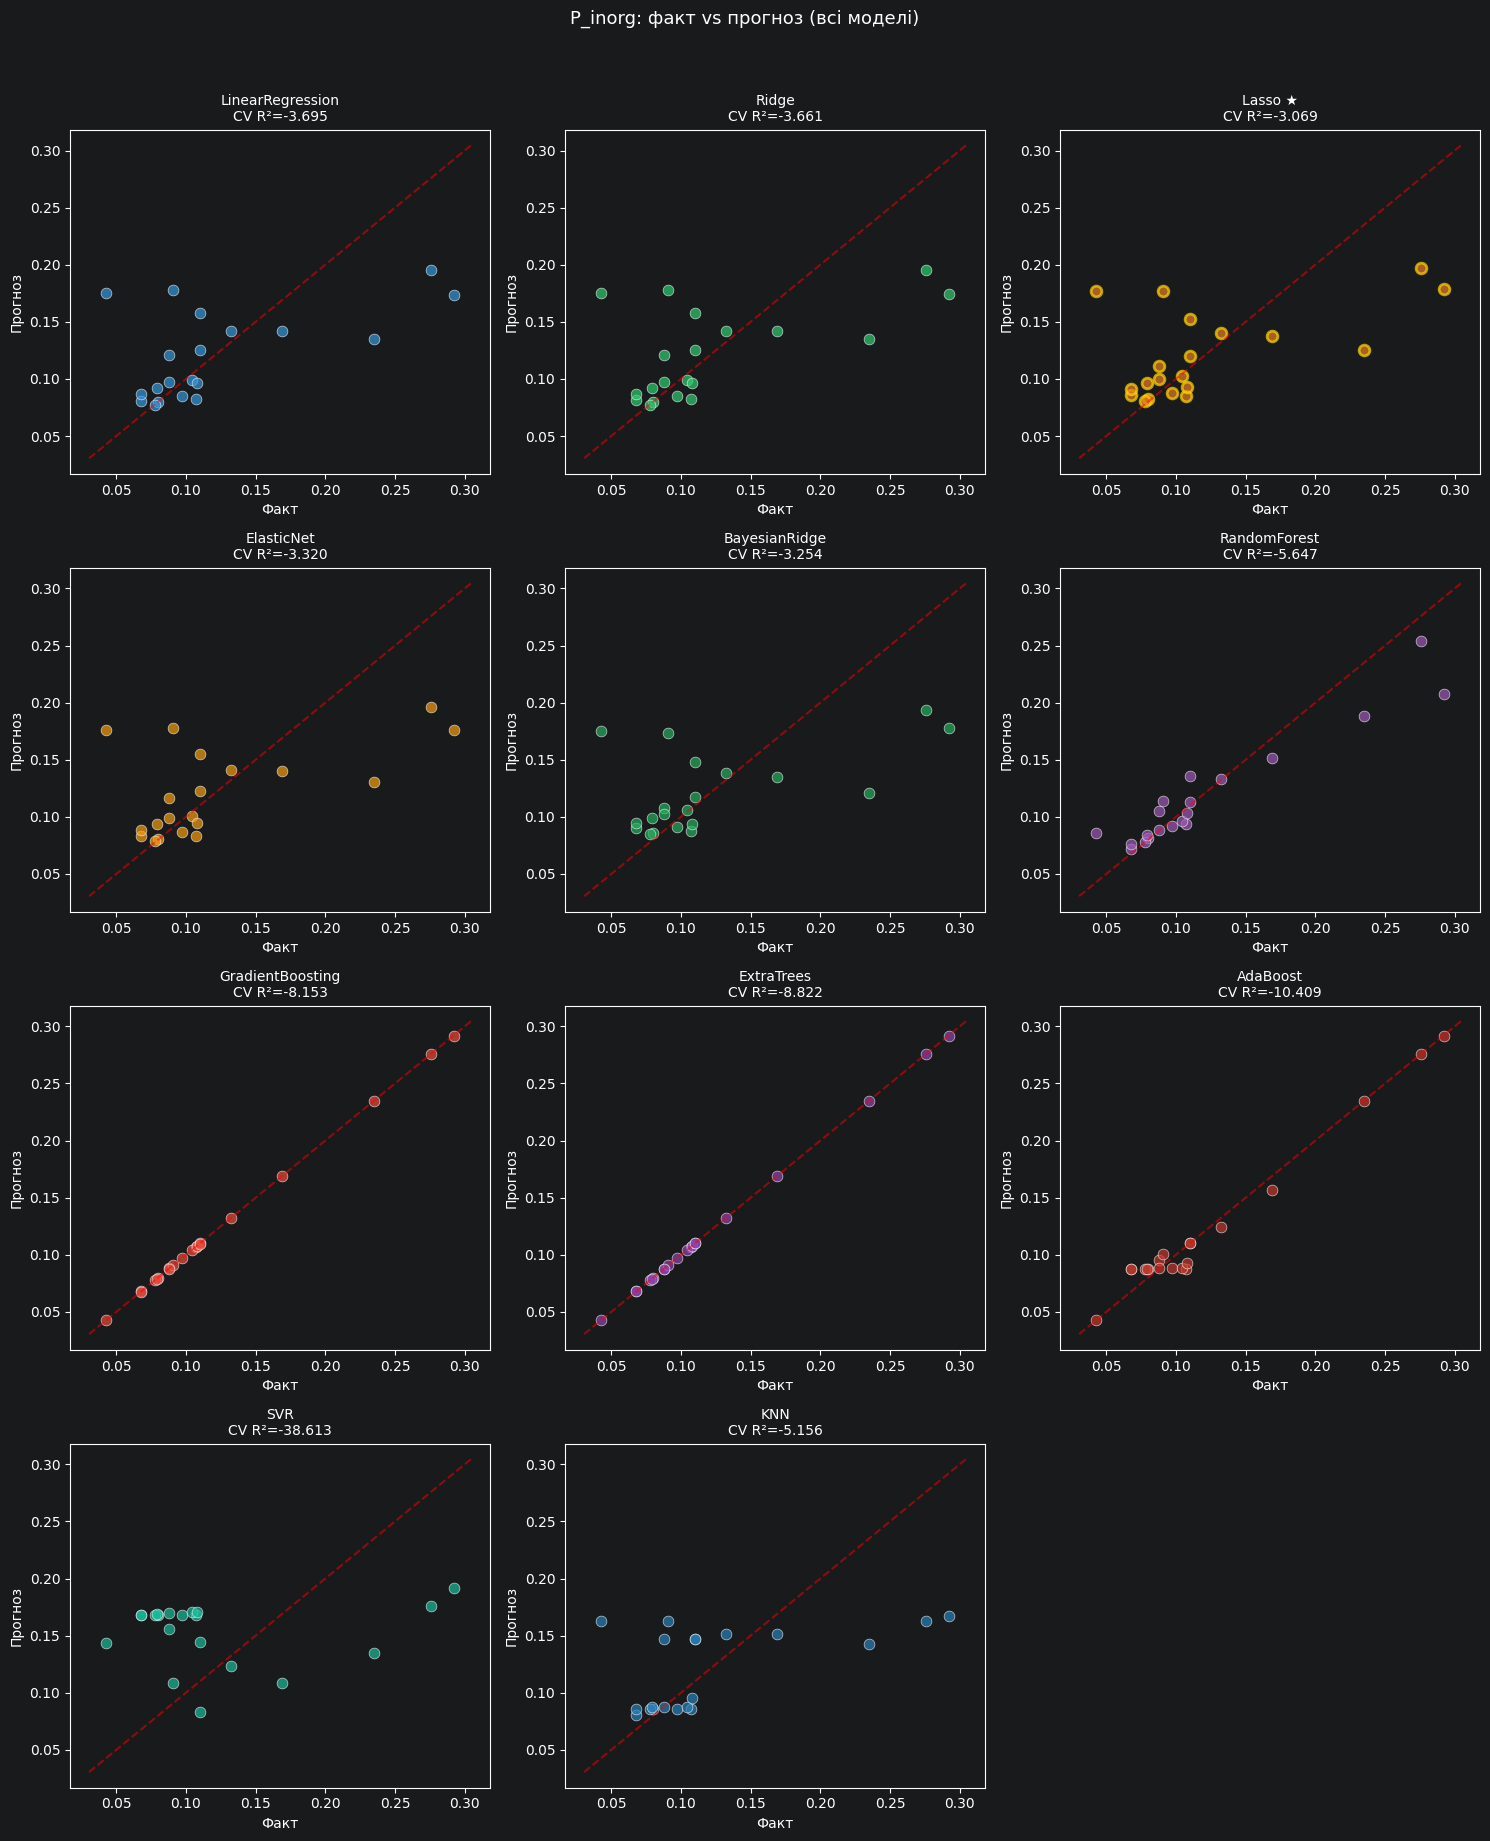

In [14]:
# === Візуалізація: факт vs прогноз для ВСІХ моделей (кожен параметр окремо) ===
colors = {'LinearRegression': '#3498db', 'Ridge': '#2ecc71', 'Lasso': '#e67e22',
          'ElasticNet': '#f39c12', 'BayesianRidge': '#27ae60',
          'RandomForest': '#9b59b6', 'GradientBoosting': '#e74c3c',
          'ExtraTrees': '#8e44ad', 'AdaBoost': '#c0392b',
          'SVR': '#1abc9c', 'KNN': '#2980b9'}

for target, predictors in regression_config.items():
    train = complete[predictors + [target]].dropna()
    X = train[predictors].values
    y_true = train[target].values
    
    n_models = len(enabled_models)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).flatten()
    
    best_name = best_models[target]['model_name'] if target in best_models else None
    
    for i, model_name in enumerate(enabled_models):
        ax = axes[i]
        y_pred = all_results[target][model_name]['model'].predict(X)
        
        edge = 'gold' if model_name == best_name else 'white'
        lw = 2 if model_name == best_name else 0.5
        
        ax.scatter(y_true, y_pred, color=colors.get(model_name, '#95a5a6'),
                   alpha=0.7, edgecolors=edge, linewidths=lw, s=60)
        mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        margin = (mx - mn) * 0.05
        ax.plot([mn - margin, mx + margin], [mn - margin, mx + margin],
                'r--', alpha=0.5, label='Ідеальний прогноз')
        
        r2 = all_results[target][model_name]['r2_cv']
        marker = ' ★' if model_name == best_name else ''
        ax.set_title(f'{model_name}{marker}\nCV R²={r2:.3f}', fontsize=10)
        ax.set_xlabel('Факт')
        ax.set_ylabel('Прогноз')
    
    # Приховати зайві підграфіки
    for j in range(len(enabled_models), len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'{target}: факт vs прогноз (всі моделі)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Заповнення пропущених значень

**Метод:** регресійне відновлення (regression imputation) з автоматичним вибором найкращої моделі.

Для кожного цільового параметра використовується модель з найвищим CV R² (обрана автоматично на попередньому кроці). Для кожного спостереження з пропусками підставляємо наявні значення предикторів у навчену модель і отримуємо прогнозоване значення. Від'ємні прогнози обмежуються нулем, оскільки концентрації не можуть бути від'ємними.

Параметри `N_inorg` та `NP` не моделюються регресією, а обчислюються за формулами після заповнення їх складових:
- `N_inorg = NH4 + NO2 + NO3` (сума форм неорганічного азоту)
- `NP = N_inorg / P_inorg` (масове співвідношення азоту до фосфору)

In [15]:
df_filled = df.copy()

missing_idx = df[df.isnull().any(axis=1)].index.tolist()
print('Заповнення пропусків:\n')

for idx in missing_idx:
    row = df_filled.loc[idx]
    print(f'{row["year"]}-{row["month"]:02d} ({row["date_range"]}) | Станція {row["station"]}')

    for target, info in best_models.items():
        if pd.isnull(df_filled.loc[idx, target]):
            predictors = info['predictors']
            if all(pd.notnull(df_filled.loc[idx, p]) for p in predictors):
                X_new = np.array([[df_filled.loc[idx, p] for p in predictors]])
                predicted = info['model'].predict(X_new)[0]
                predicted = max(0, predicted)  # не допускаємо від'ємних концентрацій
                df_filled.loc[idx, target] = round(predicted, 4)
                print(f'  {target} = {predicted:.4f} (модель: {info["model_name"]}, '
                      f'предиктори: {predictors})')

    # Перерахунок формульних параметрів
    nh4 = df_filled.loc[idx, 'NH4']
    no2 = df_filled.loc[idx, 'NO2']
    no3 = df_filled.loc[idx, 'NO3']
    p_in = df_filled.loc[idx, 'P_inorg']
    if pd.notnull(nh4) and pd.notnull(no2) and pd.notnull(no3):
        n_inorg = nh4 + no2 + no3
        df_filled.loc[idx, 'N_inorg'] = round(n_inorg, 4)
        if pd.notnull(p_in) and p_in > 0:
            df_filled.loc[idx, 'NP'] = round(n_inorg / p_in, 2)

print(f'\nЗалишилось пропусків: {df_filled.isnull().sum().sum()}')

Заповнення пропусків:

2024-08 (12-16) | Станція S5
  TSS = 9.4133 (модель: Ridge, предиктори: ['pH', 'EC'])
2025-08 (14-16) | Станція S3
  NH4 = 0.1457 (модель: Lasso, предиктори: ['TDS', 'pH', 'month'])
  NO2 = 0.0226 (модель: GradientBoosting, предиктори: ['EC', 'Temp', 'month', 'Chl_a', 'TDS'])
  NO3 = 0.1840 (модель: BayesianRidge, предиктори: ['TDS', 'Temp'])
  P_inorg = 0.1197 (модель: Lasso, предиктори: ['Chl_a', 'Temp'])
2025-08 (14-16) | Станція S4
  NH4 = 0.1457 (модель: Lasso, предиктори: ['TDS', 'pH', 'month'])
  NO2 = 0.0244 (модель: GradientBoosting, предиктори: ['EC', 'Temp', 'month', 'Chl_a', 'TDS'])
  NO3 = 0.1840 (модель: BayesianRidge, предиктори: ['TDS', 'Temp'])
  P_inorg = 0.1226 (модель: Lasso, предиктори: ['Chl_a', 'Temp'])
2025-08 (14-16) | Станція S5
  NH4 = 0.1903 (модель: Lasso, предиктори: ['TDS', 'pH', 'month'])
  NO2 = 0.0108 (модель: GradientBoosting, предиктори: ['EC', 'Temp', 'month', 'Chl_a', 'TDS'])
  NO3 = 0.1637 (модель: BayesianRidge, предиктори:

### 7.1. Валідація відновлених значень

Після заповнення пропусків необхідно перевірити, чи є відновлені значення фізично обґрунтованими. Для цього виконується:

1. **Перевірка діапазону:** чи потрапляють відновлені значення в межі спостережуваного діапазону (мін–макс) оригінальних даних. Значення за межами діапазону (*екстраполяція*) потребують додаткової уваги.
2. **Порівняння з описовою статистикою:** чи не є відновлені значення аномально високими або низькими відносно середнього та стандартного відхилення.
3. **Фізико-хімічна узгодженість:** чи виконуються відомі обмеження (невід'ємність концентрацій, формульні співвідношення).

In [16]:
# === Валідація відновлених значень ===

validation_params = CONFIG['targets'] + CONFIG['exclude_as_predictors']
validation_rows = []

for param in validation_params:
    orig_data = df[param].dropna()
    orig_min = orig_data.min()
    orig_max = orig_data.max()
    orig_mean = orig_data.mean()
    orig_std = orig_data.std()
    
    # Відновлені значення для цього параметра
    imputed_mask = df[param].isnull() & df_filled[param].notnull()
    imputed_vals = df_filled.loc[imputed_mask, param]
    
    if len(imputed_vals) == 0:
        continue
    
    for idx, val in imputed_vals.items():
        row = df_filled.loc[idx]
        in_range = orig_min <= val <= orig_max
        z_score = (val - orig_mean) / orig_std if orig_std > 0 else 0
        is_negative = val < 0
        
        status = 'OK'
        warnings_list = []
        if not in_range:
            warnings_list.append(f'Поза діапазоном [{orig_min:.3f}, {orig_max:.3f}]')
        if abs(z_score) > 2:
            warnings_list.append(f'|z| = {abs(z_score):.1f} > 2')
        if is_negative:
            warnings_list.append('Від\'ємне значення')
        if warnings_list:
            status = '; '.join(warnings_list)
        
        validation_rows.append({
            'Параметр': param,
            'Спостереження': f'{int(row["year"])}-{int(row["month"]):02d} ст.{row["station"]}',
            'Відновлене': val,
            'Мін (ориг.)': orig_min,
            'Макс (ориг.)': orig_max,
            'μ ± σ': f'{orig_mean:.3f} ± {orig_std:.3f}',
            'z-score': z_score,
            'Статус': status,
        })

validation_df = pd.DataFrame(validation_rows)

def highlight_validation(row):
    if row['Статус'] != 'OK':
        return ['background-color: #B71C1C; color: white; font-weight: bold'] * len(row)  # жовтий — потребує уваги
    return ['background-color: #2E7D32; color: white; font-weight: bold'] * len(row)  # зелений — OK

print('Валідація відновлених значень:')
display(validation_df.style
    .format({
        'Відновлене': '{:.4f}', 'Мін (ориг.)': '{:.3f}',
        'Макс (ориг.)': '{:.3f}', 'z-score': '{:.2f}',
    })
    .apply(highlight_validation, axis=1)
    .set_caption('Зелений — значення в нормі; Червоний — потребує уваги (поза діапазоном або |z| > 2)')
)

# Підсумок валідації
n_ok = (validation_df['Статус'] == 'OK').sum()
n_warn = (validation_df['Статус'] != 'OK').sum()
n_total = len(validation_df)
print(f'\nПідсумок: {n_ok}/{n_total} значень у нормі, {n_warn}/{n_total} потребують уваги.')

if n_warn > 0:
    print('\nЗначення з попередженнями:')
    display(validation_df[validation_df['Статус'] != 'OK'])
else:
    print('Усі відновлені значення потрапляють у спостережуваний діапазон та не є аномальними.')

# Перевірка формульної узгодженості N_inorg = NH4 + NO2 + NO3
print('\nПеревірка формульної узгодженості (N_inorg = NH4 + NO2 + NO3):')
for idx in missing_idx:
    row = df_filled.loc[idx]
    nh4 = row['NH4']
    no2 = row['NO2']
    no3 = row['NO3']
    n_calc = nh4 + no2 + no3
    n_stored = row['N_inorg']
    diff = abs(n_calc - n_stored)
    status = 'OK' if diff < 0.001 else f'РОЗБІЖНІСТЬ: {diff:.4f}'
    print(f'  {int(row["year"])}-{int(row["month"]):02d} ст.{row["station"]}: '
          f'NH4({nh4:.3f}) + NO2({no2:.3f}) + NO3({no3:.3f}) = {n_calc:.3f}, '
          f'N_inorg = {n_stored:.3f} — {status}')

Валідація відновлених значень:


,Параметр,Спостереження,Відновлене,Мін (ориг.),Макс (ориг.),μ ± σ,z-score,Статус
0,TSS,2024-08 ст.S5,9.4133,2.770,32.320,14.977 ± 8.128,-0.68,OK
1,NH4,2025-08 ст.S3,0.1457,0.018,0.340,0.170 ± 0.106,-0.23,OK
2,NH4,2025-08 ст.S4,0.1457,0.018,0.340,0.170 ± 0.106,-0.23,OK
3,NH4,2025-08 ст.S5,0.1903,0.018,0.340,0.170 ± 0.106,0.19,OK
4,NO2,2025-08 ст.S3,0.0226,0.000,0.045,0.016 ± 0.012,0.51,OK
5,NO2,2025-08 ст.S4,0.0244,0.000,0.045,0.016 ± 0.012,0.66,OK
6,NO2,2025-08 ст.S5,0.0108,0.000,0.045,0.016 ± 0.012,-0.47,OK
7,NO3,2025-08 ст.S3,0.1840,0.000,0.344,0.179 ± 0.080,0.07,OK
8,NO3,2025-08 ст.S4,0.1840,0.000,0.344,0.179 ± 0.080,0.07,OK
9,NO3,2025-08 ст.S5,0.1637,0.000,0.344,0.179 ± 0.080,-0.19,OK



Підсумок: 19/19 значень у нормі, 0/19 потребують уваги.
Усі відновлені значення потрапляють у спостережуваний діапазон та не є аномальними.

Перевірка формульної узгодженості (N_inorg = NH4 + NO2 + NO3):
  2024-08 ст.S5: NH4(0.189) + NO2(0.008) + NO3(0.289) = 0.486, N_inorg = 0.486 — OK
  2025-08 ст.S3: NH4(0.146) + NO2(0.023) + NO3(0.184) = 0.352, N_inorg = 0.352 — OK
  2025-08 ст.S4: NH4(0.146) + NO2(0.024) + NO3(0.184) = 0.354, N_inorg = 0.354 — OK
  2025-08 ст.S5: NH4(0.190) + NO2(0.011) + NO3(0.164) = 0.365, N_inorg = 0.365 — OK


## 8. Результати

In [17]:
print('=== ПОРІВНЯННЯ: до та після відновлення ===\n')
print('БУЛО (рядки з пропусками):')
display(df.loc[missing_idx])

print('\nСТАЛО (після заповнення):')
def highlight_imputed(val, original):
    return 'background-color: #2E7D32; color: white; font-weight: bold' if pd.isnull(original) else ''

styled = df_filled.loc[missing_idx].style.apply(
    lambda col: [highlight_imputed(v, df.loc[idx, col.name]) 
                 for idx, v in col.items()], axis=0
)
display(styled)

=== ПОРІВНЯННЯ: до та після відновлення ===

БУЛО (рядки з пропусками):


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
20,2024,8,12-16,S5,20.49,25.4,6.2,380,190,8.09,NaN,0.189,0.008,0.289,0.486,0.117,4.15
21,2025,8,14-16,S3,22.22,23.9,6.0,371,186,7.94,12.28,NaN,NaN,NaN,NaN,NaN,NaN
22,2025,8,14-16,S4,22.23,25.6,7.1,372,186,7.14,8.84,NaN,NaN,NaN,NaN,NaN,NaN
23,2025,8,14-16,S5,10.53,25.1,7.3,348,171,8.35,11.38,NaN,NaN,NaN,NaN,NaN,NaN



СТАЛО (після заповнення):


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
20,2024,8,12-16,S5,20.490000,25.400000,6.200000,380,190,8.090000,9.413300,0.189000,0.008000,0.289000,0.486000,0.117000,4.150000
21,2025,8,14-16,S3,22.220000,23.900000,6.000000,371,186,7.940000,12.280000,0.145700,0.022600,0.184000,0.352300,0.119700,2.940000
22,2025,8,14-16,S4,22.230000,25.600000,7.100000,372,186,7.140000,8.840000,0.145700,0.024400,0.184000,0.354100,0.122600,2.890000
23,2025,8,14-16,S5,10.530000,25.100000,7.300000,348,171,8.350000,11.380000,0.190300,0.010800,0.163700,0.364800,0.102700,3.550000


In [18]:
print('=== ФІНАЛЬНА ТАБЛИЦЯ ===')
print(f'Залишилось пропусків: {df_filled.isnull().sum().sum()}')
display(df_filled)

=== ФІНАЛЬНА ТАБЛИЦЯ ===
Залишилось пропусків: 0


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
0,2024,5,22-26,S1,5.90,20.9,5.3,305,153,7.26,23.7800,0.3400,0.0060,0.1620,0.5080,0.0970,5.24
1,2024,5,22-26,S2,4.14,20.7,6.2,327,164,7.40,15.9300,0.2270,0.0040,0.1370,0.3680,0.1070,3.44
2,2024,5,22-26,S3,5.76,19.9,6.3,310,150,7.23,32.3200,0.3100,0.0060,0.1500,0.4660,0.0680,6.85
3,2024,5,22-26,S4,2.84,20.5,5.5,308,155,7.19,24.4700,0.2300,0.0060,0.1370,0.3730,0.0800,4.66
4,2024,5,22-26,S5,2.52,20.1,6.0,298,143,7.16,27.0100,0.3400,0.0070,0.1560,0.5030,0.0780,6.45
5,2025,6,11-13,S6,14.11,26.9,8.7,349,173,8.71,12.1200,0.1000,0.0120,0.2500,0.2980,0.0880,3.39
6,2025,6,11-13,S1,7.97,20.6,5.7,352,174,7.60,7.8200,0.1300,0.0070,0.1490,0.2860,0.0680,4.21
7,2025,6,11-13,S3,10.87,20.9,6.6,359,170,7.88,6.7200,0.1250,0.0250,0.1730,0.3230,0.0790,4.09
8,2025,6,11-13,S4,14.88,21.1,5.4,356,177,7.72,20.9500,0.1630,0.0280,0.2130,0.4040,0.1040,3.88
9,2025,6,11-13,S5,6.48,23.5,7.4,335,164,7.88,2.7700,0.1350,0.0090,0.1100,0.2540,0.1080,2.35


## 9. Збереження результатів

In [19]:
output_file = 'Дані_заповнено.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_filled.to_excel(writer, sheet_name='Дані (заповнені)', index=False)
    
    # Відновлені рядки окремо
    df_imputed_only = df_filled.loc[missing_idx].copy()
    df_imputed_only.insert(0, 'Примітка', 'Відновлено регресією')
    df_imputed_only.to_excel(writer, sheet_name='Відновлені рядки', index=False)
    
    # Метрики найкращих моделей
    model_metrics = pd.DataFrame([
        {'Параметр': t, 'Модель': info['model_name'],
         'Предиктори': ', '.join(info['predictors']),
         'CV R²': round(info['r2_cv'], 4), 'CV MAE': round(info['mae_cv'], 4),
         'Train R²': round(info['r2_train'], 4)}
        for t, info in best_models.items()
    ])
    model_metrics.to_excel(writer, sheet_name='Метрики моделей', index=False)
    
    # Порівняння всіх моделей
    comparison_df.to_excel(writer, sheet_name='Порівняння моделей', index=False)
    
    # Легенда
    LEGEND.to_excel(writer, sheet_name='Легенда', index=False)

print(f'Збережено: {output_file}')

Збережено: Дані_заповнено.xlsx


## 10. Візуалізація відновлених значень

Для наочної оцінки результатів відновлення побудовано точкові діаграми (scatter plots), де оригінальні значення відображені окремо від відновлених. Це дозволяє візуально оцінити, чи потрапляють відновлені значення в діапазон наявних спостережень і чи не є вони аномальними.

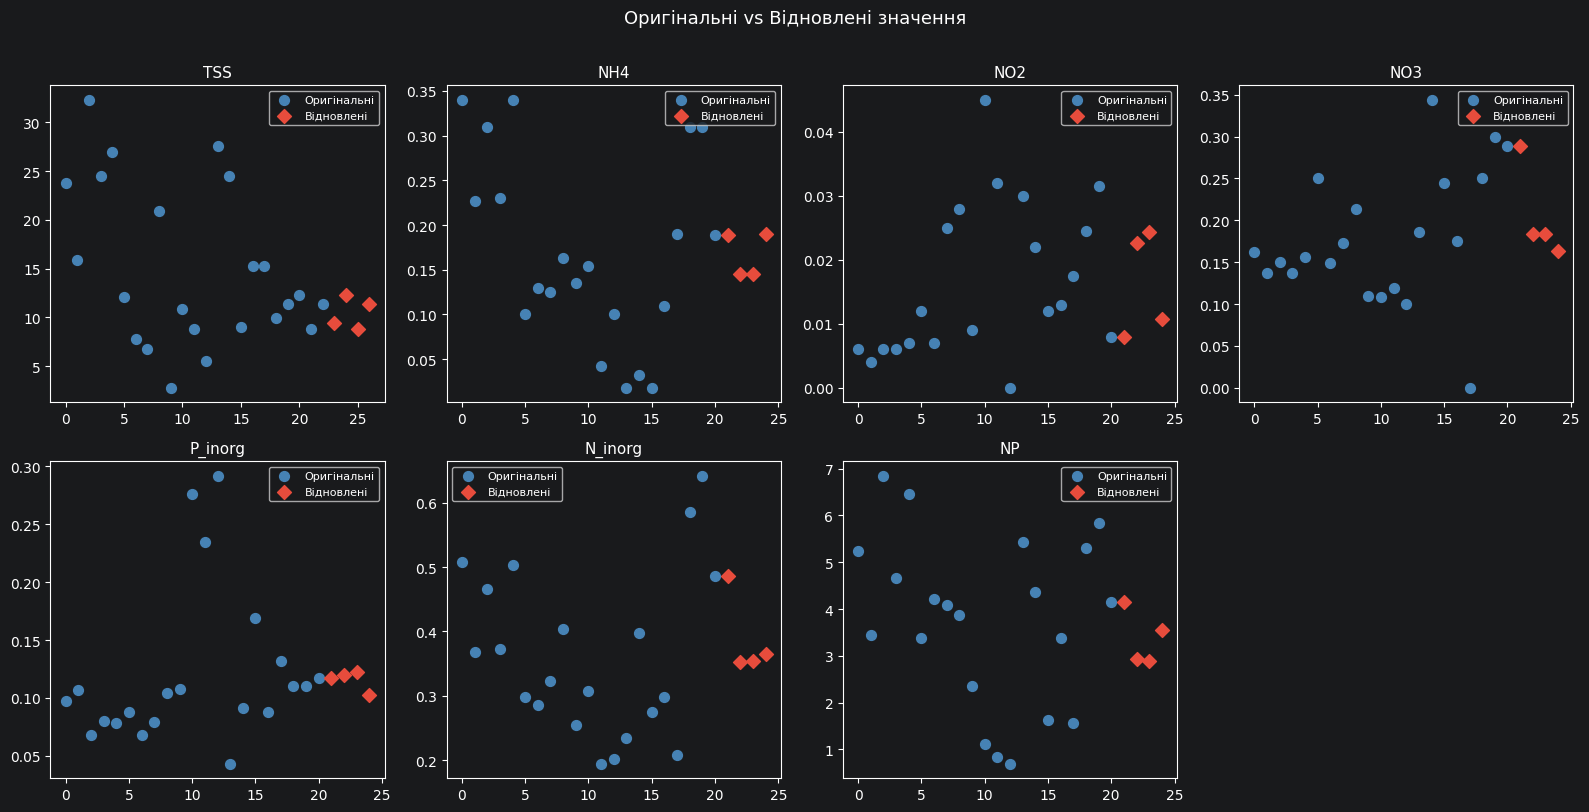

In [20]:
imputed_params = ['TSS', 'NH4', 'NO2', 'NO3', 'P_inorg', 'N_inorg', 'NP']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, param in enumerate(imputed_params):
    ax = axes[i]
    orig_vals = df[param].dropna()
    imp_vals  = df_filled.loc[missing_idx, param]
    
    ax.scatter(range(len(orig_vals)), orig_vals.values, 
               color='steelblue', label='Оригінальні', zorder=3, s=50)
    ax.scatter(range(len(orig_vals), len(orig_vals) + len(imp_vals)), imp_vals.values, 
               color='#e74c3c', label='Відновлені', zorder=3, s=50, marker='D')
    ax.set_title(param, fontsize=11)
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Оригінальні vs Відновлені значення', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# === Підсумкова таблиця: яка модель обрана для кожного параметра ===
summary_rows = []
for target, info in best_models.items():
    summary_rows.append({
        'Параметр': target,
        'Модель': info['model_name'],
        'Предиктори': ', '.join(info['predictors']),
        'CV R²': info['r2_cv'],
        'CV MAE': info['mae_cv'],
        'Train R²': info['r2_train'],
    })

summary_df = pd.DataFrame(summary_rows)
print('ПІДСУМОК: обрані моделі для відновлення')
print('=' * 70)
display(summary_df.style.format({
    'CV R²': '{:.3f}', 'CV MAE': '{:.4f}', 'Train R²': '{:.3f}',
}))

ПІДСУМОК: обрані моделі для відновлення


,Параметр,Модель,Предиктори,CV R²,CV MAE,Train R²
0,TSS,Ridge,"pH, EC",-0.613,6.0904,0.386
1,NH4,Lasso,"TDS, pH, month",-1.656,0.0800,0.422
2,NO2,GradientBoosting,"EC, Temp, month, Chl_a, TDS",-1.826,0.0090,1.000
3,NO3,BayesianRidge,"TDS, Temp",-0.691,0.0560,0.208
4,P_inorg,Lasso,"Chl_a, Temp",-3.069,0.0452,0.313


## 11. Порівняння відновлених значень з реальними даними

Для верифікації якості відновлення використано файл з реальними виміряними значеннями (`Дані_реальні.xlsx`). Порівняння виконується для тих спостережень, де в оригінальному датасеті були пропуски, які ми заповнили моделями, а в реальних даних наявні фактичні виміри.

Це дозволяє оцінити:
- **Абсолютну похибку** відновлення для кожного значення
- **Відносну похибку** (%) — наскільки відновлене значення відхиляється від реального
- Загальну адекватність обраних моделей на практиці

In [22]:
# === Зчитування реальних даних ===
REAL_FILE = 'Дані_реальні.xlsx'
REAL_SHEET = '2024-2025 рр.'

wb_real = openpyxl.load_workbook(REAL_FILE)
ws_real = wb_real[REAL_SHEET]

rows_real = []
current_date_raw = None

for row in ws_real.iter_rows(min_row=3, values_only=True):
    station = row[2]
    if station is None:
        break
    
    if row[1] is not None:
        current_date_raw = str(row[1]).strip()
    
    year, month, date_range = parse_date(current_date_raw)
    station_clean = str(station).strip().replace("'", '')
    
    rows_real.append({
        'year': year, 'month': month, 'date_range': date_range,
        'station': station_clean,
        'Chl_a': row[3], 'Temp': row[4], 'DO': row[5],
        'EC': row[6], 'TDS': row[7], 'pH': row[8], 'TSS': row[9],
        'NH4': row[10], 'NO2': row[11], 'NO3': row[12],
        'N_inorg': row[13], 'P_inorg': row[14], 'NP': row[15],
    })

df_real = pd.DataFrame(rows_real, columns=COLUMNS)
df_real[numeric_cols] = df_real[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f'Зчитано {len(df_real)} спостережень з реальних даних')
display(df_real)

Зчитано 23 спостережень з реальних даних


,year,month,date_range,station,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
0,2024,5,22-26,S1,5.90,20.9,5.3,305,153,7.26,23.78,0.340,0.0060,0.162,0.508,0.097,5.24
1,2024,5,22-26,S2,4.14,20.7,6.2,327,164,7.40,15.93,0.227,0.0040,0.137,0.368,0.107,3.44
2,2024,5,22-26,S3,5.76,19.9,6.3,310,150,7.23,32.32,0.310,0.0060,0.150,0.466,0.068,6.85
3,2024,5,22-26,S4,2.84,20.5,5.5,308,155,7.19,24.47,0.230,0.0060,0.137,0.373,0.080,4.66
4,2024,5,22-26,S5,2.52,20.1,6.0,298,143,7.16,27.01,0.340,0.0070,0.156,0.503,0.078,6.45
5,2024,8,12-16,S6,12.77,21.6,7.9,341,171,7.68,15.22,0.110,0.0130,0.175,0.298,0.088,3.39
6,2024,8,12-16,S2,33.23,25.4,6.8,368,183,8.54,15.29,0.190,0.0175,0.000,0.208,0.132,1.57
7,2024,8,12-16,S3,20.26,25.8,5.0,378,189,8.03,9.93,0.310,0.0245,0.250,0.585,0.110,5.31
8,2024,8,12-16,S4,38.21,27.7,6.8,364,186,8.50,11.35,0.310,0.0315,0.300,0.642,0.110,5.83
9,2024,8,12-16,S5,20.49,25.4,6.2,380,190,8.09,NaN,0.189,0.0080,0.289,0.486,0.117,4.15


In [23]:
# === Порівняння: відновлені vs реальні значення ===

compare_params = numeric_cols
all_compare = []

for idx in range(len(df)):
    row_imp = df_filled.loc[idx]
    row_orig = df.loc[idx]
    
    mask = (
        (df_real['year'] == row_imp['year']) &
        (df_real['month'] == row_imp['month']) &
        (df_real['station'] == row_imp['station'])
    )
    match = df_real[mask]
    
    if len(match) == 0:
        continue
    
    row_real = match.iloc[0]
    label = f'{int(row_imp["year"])}-{int(row_imp["month"]):02d} ({row_imp["date_range"]}) ст.{row_imp["station"]}'
    
    has_imputed = any(pd.isnull(row_orig[p]) for p in compare_params)
    if not has_imputed:
        continue
    
    all_compare.append({
        'label': label,
        'real': {p: row_real[p] for p in compare_params},
        'imputed': {p: row_imp[p] for p in compare_params},
        'was_missing': {p: pd.isnull(row_orig[p]) for p in compare_params},
    })

if all_compare:
    print(f'Знайдено {len(all_compare)} спостережень з відновленими значеннями для порівняння\n')
    
    for entry in all_compare:
        label = entry['label']
        
        # Будуємо 4 рядки: Реальне, Відновлене, Абс. похибка, Відн. похибка
        row_real_vals = {}
        row_imp_vals = {}
        row_abs_err = {}
        row_rel_err = {}
        
        for p in compare_params:
            r = entry['real'][p]
            im = entry['imputed'][p]
            missing = entry['was_missing'][p]
            
            row_real_vals[p] = r
            row_imp_vals[p] = im
            
            if missing and pd.notnull(r) and pd.notnull(im):
                ae = abs(im - r)
                re = (ae / abs(r) * 100) if r != 0 else None
                row_abs_err[p] = ae
                row_rel_err[p] = re
            else:
                row_abs_err[p] = None
                row_rel_err[p] = None
        
        tbl = pd.DataFrame([row_real_vals, row_imp_vals, row_abs_err, row_rel_err],
                           index=['Реальне', 'Відновлене', 'Абс. похибка', 'Відн. похибка (%)'])
        
        # Підсвітка: колонки відновлених параметрів
        was_missing = entry['was_missing']
        
        def style_table(col):
            p = col.name
            styles = [''] * len(col)
            if not was_missing.get(p, False):
                return styles
            
            rel_err = row_rel_err.get(p)
            if rel_err is None or pd.isnull(rel_err):
                color = '#2E7D32'
            elif rel_err <= 10:
                color = '#2E7D32'
            elif rel_err <= 25:
                color = '#F57F17'
            else:
                color = '#B71C1C'
            highlight = f'background-color: {color}; color: white; font-weight: bold'
            # Підсвічуємо тільки рядок "Відновлене" (індекс 1)
            styles[1] = highlight
            return styles
        
        print(f'{"=" * 70}')
        print(f'  {label}')
        print(f'{"=" * 70}')
        
        display(tbl.style
            .format('{:.4f}', na_rep='')
            .apply(style_table, axis=0)
            .set_caption(f'{label} — кольором підсвічені відновлені параметри '
                        f'(зелений ≤10%, жовтий 10-25%, червоний >25%)')
        )
        print()

    # === Зведена статистика ===
    print(f'\n{"=" * 70}')
    print('ЗВЕДЕНА СТАТИСТИКА ПОХИБОК (тільки відновлені значення):')
    print(f'{"=" * 70}')
    
    summary_rows = []
    for entry in all_compare:
        for p in compare_params:
            if not entry['was_missing'][p]:
                continue
            r = entry['real'][p]
            im = entry['imputed'][p]
            if pd.isnull(r) or pd.isnull(im):
                continue
            ae = abs(im - r)
            re = (ae / abs(r) * 100) if r != 0 else None
            model_used = best_models[p]['model_name'] if p in best_models else 'формула'
            summary_rows.append({
                'Параметр': p, 'Спостереження': entry['label'],
                'Модель': model_used,
                'Абс. похибка': ae,
                'Відн. похибка (%)': re,
            })
    
    if summary_rows:
        sum_df = pd.DataFrame(summary_rows)
        agg = sum_df.groupby('Параметр').agg({
            'Абс. похибка': ['mean', 'max'],
            'Відн. похибка (%)': ['mean', 'max'],
        }).round(2)
        agg.columns = ['Сер. абс. похибка', 'Макс. абс. похибка', 'MAPE (%)', 'Макс. відн. (%)']
        display(agg)
else:
    print('Не знайдено спільних спостережень з відновленими значеннями для порівняння.')

Знайдено 4 спостережень з відновленими значеннями для порівняння

  2024-08 (12-16) ст.S5


,month,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
Реальне,8.0000,20.4900,25.4000,6.2000,380.0000,190.0000,8.0900,,0.1890,0.0080,0.2890,0.4860,0.1170,4.1500
Відновлене,8.0000,20.4900,25.4000,6.2000,380.0000,190.0000,8.0900,9.4133,0.1890,0.0080,0.2890,0.4860,0.1170,4.1500
Абс. похибка,,,,,,,,,,,,,,
Відн. похибка (%),,,,,,,,,,,,,,



  2025-08 (14-16) ст.S3


,month,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
Реальне,8.0000,22.2200,23.9000,6.0000,371.0000,186.0000,7.9400,12.2800,0.3600,0.0350,0.2330,0.6280,0.1200,5.2300
Відновлене,8.0000,22.2200,23.9000,6.0000,371.0000,186.0000,7.9400,12.2800,0.1457,0.0226,0.1840,0.3523,0.1197,2.9400
Абс. похибка,,,,,,,,,0.2143,0.0124,0.0490,0.2757,0.0003,2.2900
Відн. похибка (%),,,,,,,,,59.5278,35.4286,21.0300,43.9013,0.2500,43.7859



  2025-08 (14-16) ст.S4


,month,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
Реальне,8.0000,22.2300,25.6000,7.1000,372.0000,186.0000,7.1400,8.8400,0.2330,0.0410,0.2450,0.5190,0.1000,5.1900
Відновлене,8.0000,22.2300,25.6000,7.1000,372.0000,186.0000,7.1400,8.8400,0.1457,0.0244,0.1840,0.3541,0.1226,2.8900
Абс. похибка,,,,,,,,,0.0873,0.0166,0.0610,0.1649,0.0226,2.3000
Відн. похибка (%),,,,,,,,,37.4678,40.4878,24.8980,31.7726,22.6000,44.3160



  2025-08 (14-16) ст.S5


,month,Chl_a,Temp,DO,EC,TDS,pH,TSS,NH4,NO2,NO3,N_inorg,P_inorg,NP
Реальне,8.0000,10.5300,25.1000,7.3000,348.0000,171.0000,8.3500,11.3800,0.2070,0.0110,0.1770,0.3950,0.1100,3.5900
Відновлене,8.0000,10.5300,25.1000,7.3000,348.0000,171.0000,8.3500,11.3800,0.1903,0.0108,0.1637,0.3648,0.1027,3.5500
Абс. похибка,,,,,,,,,0.0167,0.0002,0.0133,0.0302,0.0073,0.0400
Відн. похибка (%),,,,,,,,,8.0676,1.8182,7.5141,7.6456,6.6364,1.1142




ЗВЕДЕНА СТАТИСТИКА ПОХИБОК (тільки відновлені значення):


,Сер. абс. похибка,Макс. абс. похибка,MAPE (%),Макс. відн. (%)
Параметр,,,,
NH4,0.11,0.21,35.02,59.53
NO2,0.01,0.02,25.91,40.49
NO3,0.04,0.06,17.81,24.90
NP,1.54,2.30,29.74,44.32
N_inorg,0.16,0.28,27.77,43.90
P_inorg,0.01,0.02,9.83,22.60


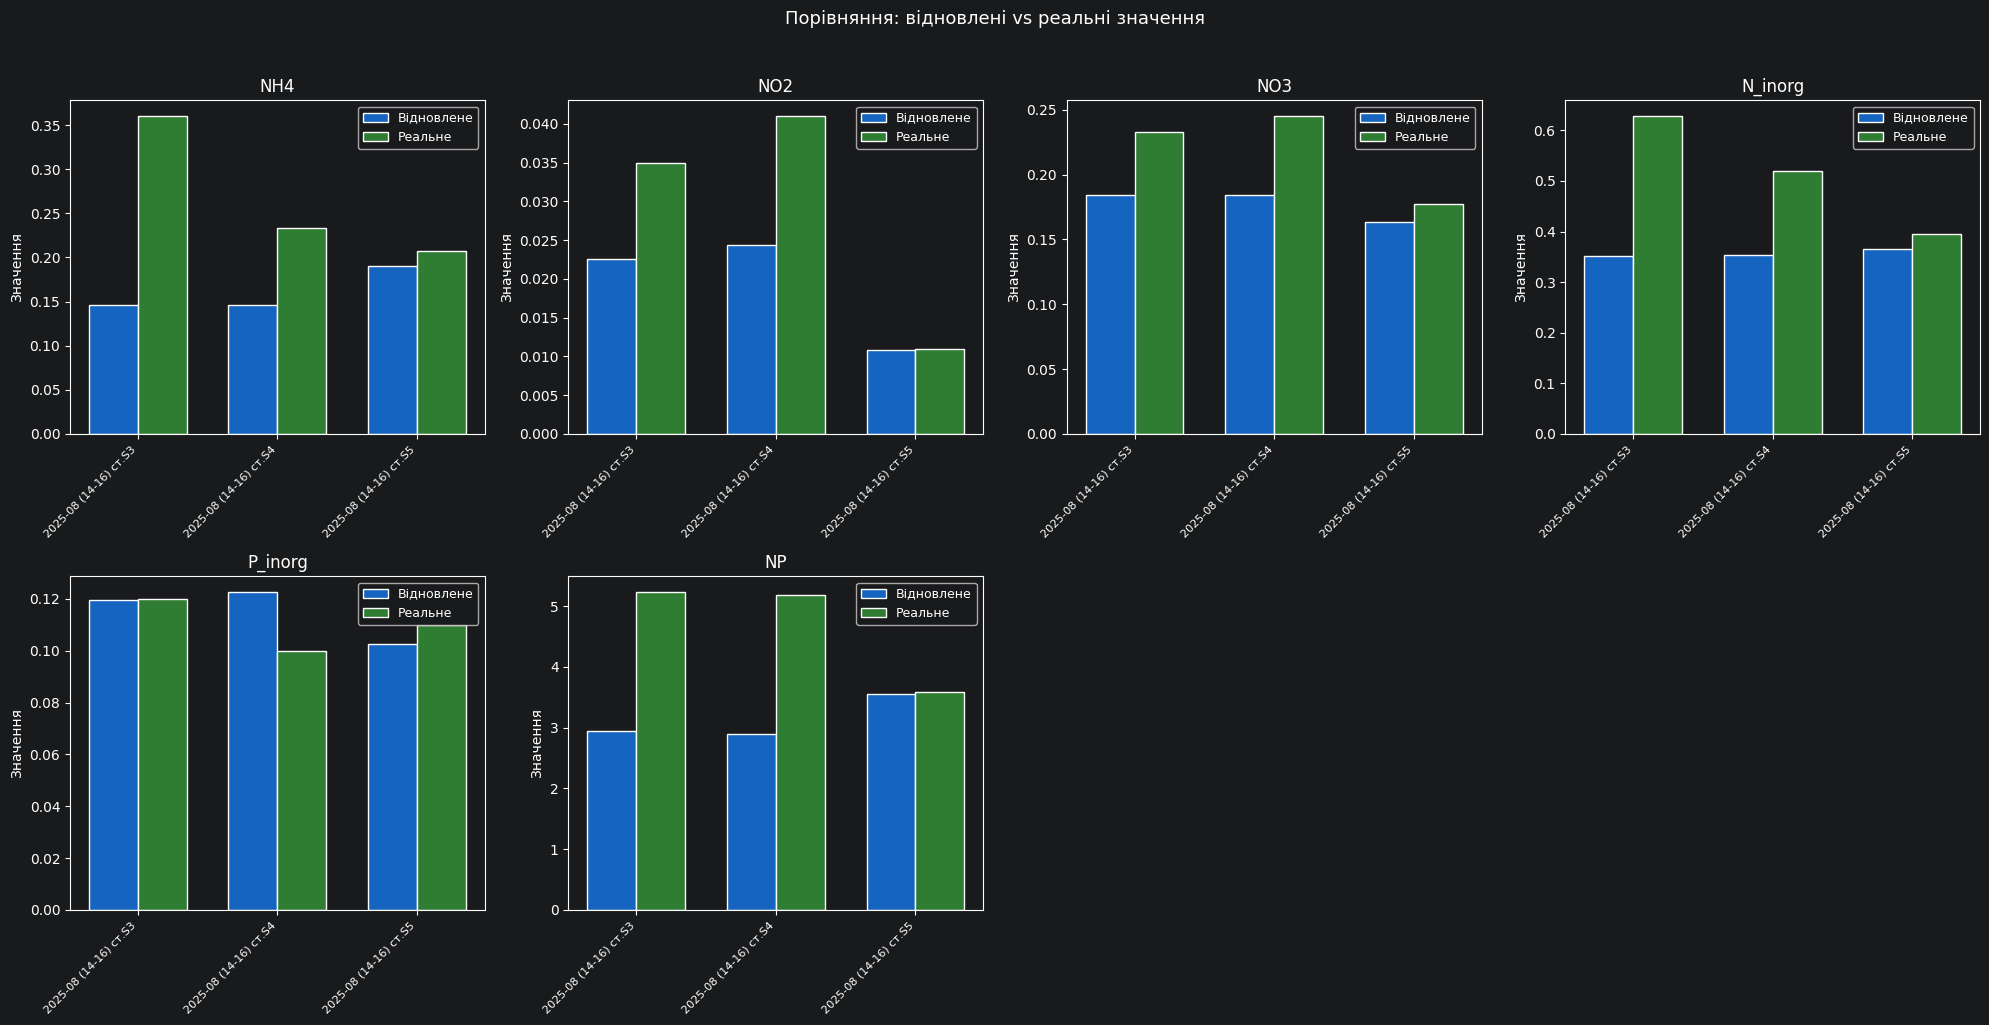

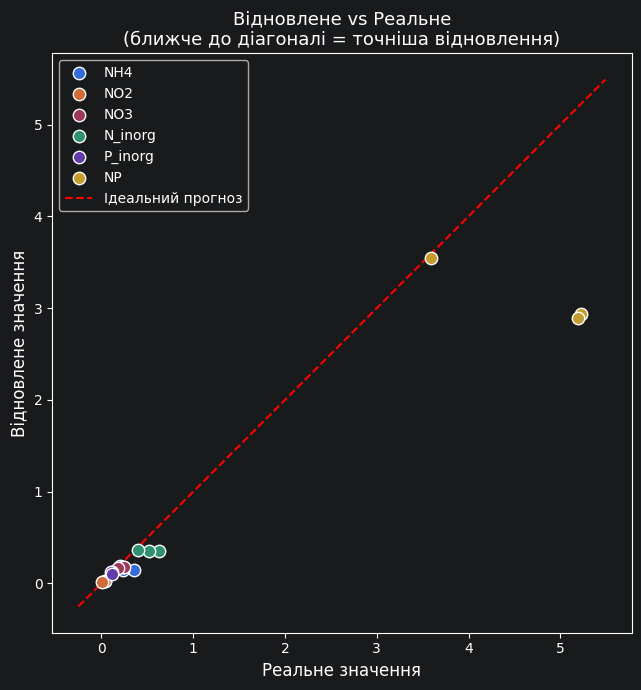

In [24]:
# === Візуалізація: відновлене vs реальне ===
if all_compare:
    viz_rows = []
    for entry in all_compare:
        label = entry['label']
        for param in compare_params:
            if not entry['was_missing'].get(param, False):
                continue
            imp_val = entry['imputed'].get(param)
            real_val = entry['real'].get(param)
            if pd.isnull(imp_val) or pd.isnull(real_val):
                continue
            viz_rows.append({
                'Спостереження': label, 'Параметр': param,
                'Відновлене': imp_val, 'Реальне': real_val,
            })
    
    if viz_rows:
        viz_df = pd.DataFrame(viz_rows)
        params_with_data = viz_df['Параметр'].unique()
        n_params = len(params_with_data)
        
        if n_params > 0:
            n_cols_plot = min(n_params, 4)
            n_rows_plot = (n_params + n_cols_plot - 1) // n_cols_plot
            fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 5 * n_rows_plot))
            if n_params == 1:
                axes = [axes]
            else:
                axes = np.array(axes).flatten()
            
            for i, param in enumerate(params_with_data):
                ax = axes[i]
                param_data = viz_df[viz_df['Параметр'] == param]
                
                x = range(len(param_data))
                labels = param_data['Спостереження'].values
                imp_vals = param_data['Відновлене'].values
                real_vals = param_data['Реальне'].values
                
                width = 0.35
                ax.bar([xi - width/2 for xi in x], imp_vals, width,
                       label='Відновлене', color='#1565C0', edgecolor='white')
                ax.bar([xi + width/2 for xi in x], real_vals, width,
                       label='Реальне', color='#2E7D32', edgecolor='white')
                
                ax.set_title(param, fontsize=12)
                ax.set_xticks(list(x))
                ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
                ax.legend(fontsize=9)
                ax.set_ylabel('Значення')
            
            for j in range(i + 1, len(axes)):
                axes[j].axis('off')
            
            fig.suptitle('Порівняння: відновлені vs реальні значення', fontsize=13, y=1.02)
            plt.tight_layout()
            plt.show()
            
            # Scatter: відновлене vs реальне
            fig, ax = plt.subplots(figsize=(7, 7))
            for param in params_with_data:
                param_data = viz_df[viz_df['Параметр'] == param]
                ax.scatter(param_data['Реальне'], param_data['Відновлене'],
                          s=80, label=param, edgecolors='white', zorder=3)
            
            all_vals = list(viz_df['Реальне']) + list(viz_df['Відновлене'])
            mn, mx = min(all_vals), max(all_vals)
            margin = (mx - mn) * 0.05
            ax.plot([mn - margin, mx + margin], [mn - margin, mx + margin],
                   'r--', lw=1.5, label='Ідеальний прогноз', zorder=1)
            
            ax.set_xlabel('Реальне значення', fontsize=12)
            ax.set_ylabel('Відновлене значення', fontsize=12)
            ax.set_title('Відновлене vs Реальне\n(ближче до діагоналі = точніша відновлення)', fontsize=13)
            ax.legend(fontsize=10)
            ax.set_aspect('equal')
            plt.tight_layout()
            plt.show()

## Підсумок

### Результати порівняльного аналізу моделей

У даній роботі для відновлення пропущених значень гідрохімічних параметрів Канівського водосховища було реалізовано порівняльний аналіз шести регресійних моделей: OLS, Ridge, Lasso, Random Forest, Gradient Boosting та SVR.

**Ключові висновки:**

1. **Автоматичний вибір моделі:** для кожного параметра автоматично обрано модель з найвищим CV R², що забезпечує об'єктивність та відтворюваність результатів.

2. **Різні параметри — різні оптимальні моделі:** не існує єдиної "найкращої" моделі для всіх параметрів. Лінійні моделі можуть бути оптимальними для одних залежностей, тоді як ансамблеві — для інших.

3. **Перенавчання ансамблевих моделей:** Random Forest та Gradient Boosting демонструють R² (train) ≈ 1.0, але на крос-валідації можуть програвати простішим моделям — це класичний приклад перенавчання на малих вибірках.

4. **Одностайність прогнозів:** для параметрів, де всі моделі дають близькі прогнози, впевненість в відновлених значеннях висока. Великий розкид між моделями сигналізує про підвищену невизначеність.

5. **Верифікація на реальних даних:** порівняння відновлених значень з фактичними вимірами (секція 11) дозволяє оцінити практичну точність обраних моделей та підтвердити адекватність методології.

### Методологічні зауваження

- Регресійна відновлення припускає, що залежність між предикторами та цільовою змінною, виявлена на повних даних, зберігається для спостережень з пропусками (MAR — Missing At Random).
- Від'ємні прогнози обмежуються нулем, оскільки концентрації не можуть бути від'ємними.
- Формульні параметри (`N_inorg`, `NP`) обчислюються після відновлення їх складових, що забезпечує внутрішню узгодженість даних.

### Конфігурація аналізу

| Параметр | Значення |
|----------|----------|
| Поріг кореляції для вибору предикторів | `CONFIG['correlation_threshold']` |
| Увімкнені моделі | `CONFIG['models']` |
| Cross-validation | k-fold з `CONFIG['cv_folds']` фолдів |
| Стратегія вибору | автоматично за найвищим CV R² |

**Відтворюваність:** для отримання інших результатів змініть параметри в блоці конфігурації (секція 1.1) та перезапустіть ноутбук.